# IMPORT LIBRARIES & LOAD DATASET

In [2]:
import pandas as pd
import numpy as np
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [4]:
womens_world_cup_stats = pd.read_csv(
    '/Users/gui/womens_world_cup_2023_statsbomb_plusplus.csv'
)

In [6]:
womens_world_cup_stats

,match_id,match_date,team,opponent,stage,goals_for,goals_against,result,points,possession_pct,...,dribbles,successful_dribbles,dribble_success_pct,duels,duels_won,counterpress_actions,goals_from_shots,own_goals_for,own_goals_against,goal_type
0,3893787,2023-07-20,New Zealand Women's,Norway Women's,Group,1,0,W,3,57.781529,...,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,Goal
1,3893787,2023-07-20,Norway Women's,New Zealand Women's,Group,0,1,L,0,42.218471,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,Goal
2,3893788,2023-07-20,Australia Women's,Republic of Ireland Women's,Group,1,0,W,3,58.013378,...,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,Goal
3,3893788,2023-07-20,Republic of Ireland Women's,Australia Women's,Group,0,1,L,0,41.986622,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,Goal
4,3893789,2023-07-21,Philippines Women's,Switzerland Women's,Group,0,2,L,0,30.212373,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,Goal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,3904629,2023-08-16,England Women's,Australia Women's,Semi-finals,3,1,W,3,49.971523,...,NaN,NaN,NaN,NaN,NaN,NaN,3,0,0,Goal
124,3906389,2023-08-19,Australia Women's,Sweden Women's,Third-place,0,2,L,0,52.821967,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,Goal
125,3906389,2023-08-19,Sweden Women's,Australia Women's,Third-place,2,0,W,3,47.178033,...,NaN,NaN,NaN,NaN,NaN,NaN,2,0,0,Goal
126,3906390,2023-08-20,England Women's,Spain Women's,Final,0,1,L,0,44.284665,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,Goal


# FILTER ROUND OF 16

In [9]:
r16 = womens_world_cup_stats[
    womens_world_cup_stats['stage'] == 'Round of 16'
]

In [11]:
r16

,match_id,match_date,team,opponent,stage,goals_for,goals_against,result,points,possession_pct,...,dribbles,successful_dribbles,dribble_success_pct,duels,duels_won,counterpress_actions,goals_from_shots,own_goals_for,own_goals_against,goal_type
96,3901733,2023-08-05,Spain Women's,Switzerland Women's,Round of 16,5,1,W,3,68.915293,...,12.0,9.0,75.00,28.0,12.0,65.0,5,0,1,Goal
97,3901733,2023-08-05,Switzerland Women's,Spain Women's,Round of 16,1,5,L,0,31.084707,...,9.0,5.0,55.56,38.0,12.0,67.0,0,1,0,Goal + Own Goal
98,3901734,2023-08-05,Japan Women's,Norway Women's,Round of 16,3,1,W,3,59.219881,...,2.0,1.0,50.00,38.0,8.0,49.0,2,1,0,Goal + Own Goal
99,3901734,2023-08-05,Norway Women's,Japan Women's,Round of 16,1,3,L,0,40.780119,...,9.0,2.0,22.22,22.0,3.0,50.0,1,0,1,Goal
100,3901796,2023-08-06,Netherlands Women's,South Africa Women's,Round of 16,2,0,W,3,70.757060,...,13.0,5.0,38.46,41.0,20.0,79.0,2,0,0,Goal
101,3901796,2023-08-06,South Africa Women's,Netherlands Women's,Round of 16,0,2,L,0,29.242940,...,35.0,18.0,51.43,45.0,14.0,56.0,0,0,0,Goal
102,3901797,2023-08-06,Sweden Women's,United States Women's,Round of 16,0,0,D,1,39.728930,...,10.0,3.0,30.00,54.0,14.0,82.0,0,0,0,Goal
103,3901797,2023-08-06,United States Women's,Sweden Women's,Round of 16,0,0,D,1,60.271070,...,25.0,18.0,72.00,53.0,16.0,70.0,0,0,0,Goal
104,3901735,2023-08-07,England Women's,Nigeria Women's,Round of 16,0,0,D,1,49.948365,...,18.0,7.0,38.89,54.0,11.0,55.0,0,0,0,Goal
105,3901735,2023-08-07,Nigeria Women's,England Women's,Round of 16,0,0,D,1,50.051635,...,16.0,7.0,43.75,57.0,20.0,74.0,0,0,0,Goal


## FILTER JUST THE GAMES

In [14]:
games = womens_world_cup_stats[
    womens_world_cup_stats["stage"] == "Round of 16"
]

games[
    ["match_id", "team", "opponent", "stage"]
].drop_duplicates("match_id")

,match_id,team,opponent,stage
96,3901733,Spain Women's,Switzerland Women's,Round of 16
98,3901734,Japan Women's,Norway Women's,Round of 16
100,3901796,Netherlands Women's,South Africa Women's,Round of 16
102,3901797,Sweden Women's,United States Women's,Round of 16
104,3901735,England Women's,Nigeria Women's,Round of 16
106,3901736,Australia Women's,Denmark Women's,Round of 16
108,3901832,Colombia Women's,Jamaica Women's,Round of 16
110,3901833,France Women's,Morocco Women's,Round of 16


# GAME ANALYSIS ENG-NGA

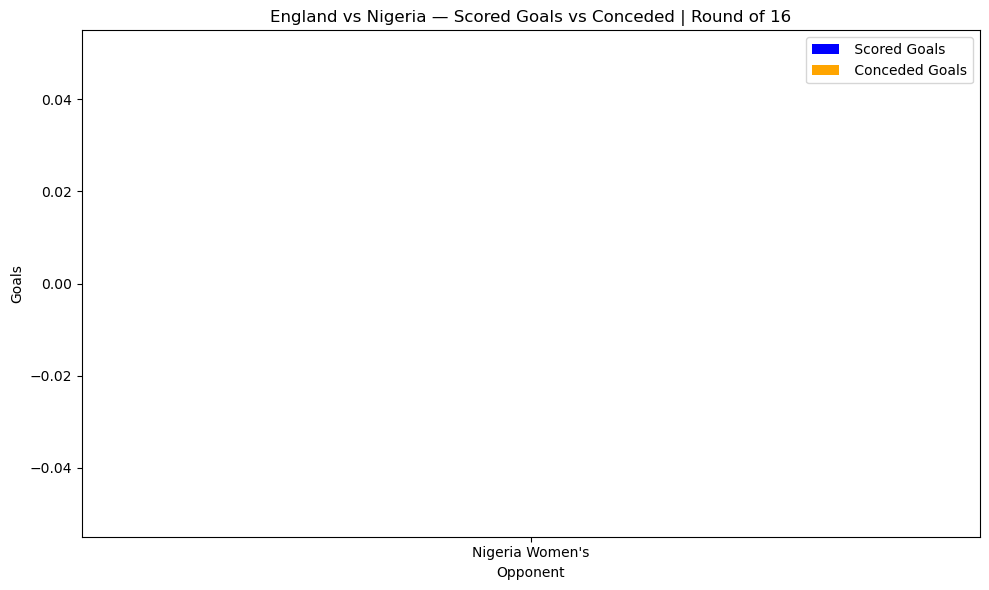

In [24]:
r16 = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "England Women's") &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()

r16["match_date"] = pd.to_datetime(r16["match_date"])

r16 = r16.sort_values("match_date")

x = np.arange(len(r16))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    r16["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    r16["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    r16["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("England vs Nigeria — Scored Goals vs Conceded | Round of 16")

plt.legend()

plt.tight_layout()
plt.show()

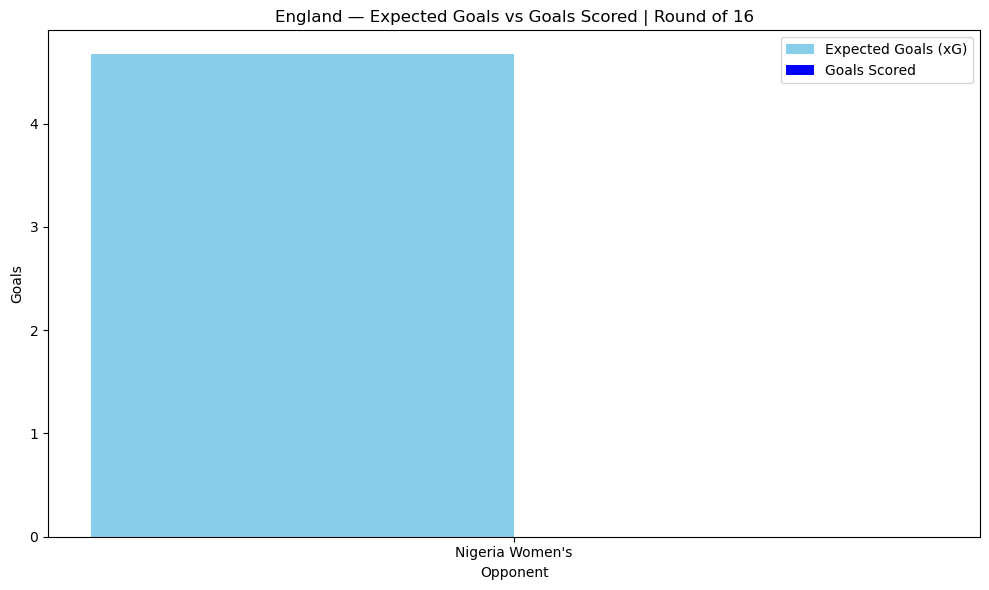

In [26]:
r16 = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "England Women's") &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()

r16["match_date"] = pd.to_datetime(r16["match_date"])

r16 = r16.sort_values("match_date")

x = np.arange(len(r16))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    r16["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    r16["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    r16["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("England — Expected Goals vs Goals Scored | Round of 16")

plt.legend()

plt.tight_layout()
plt.show()

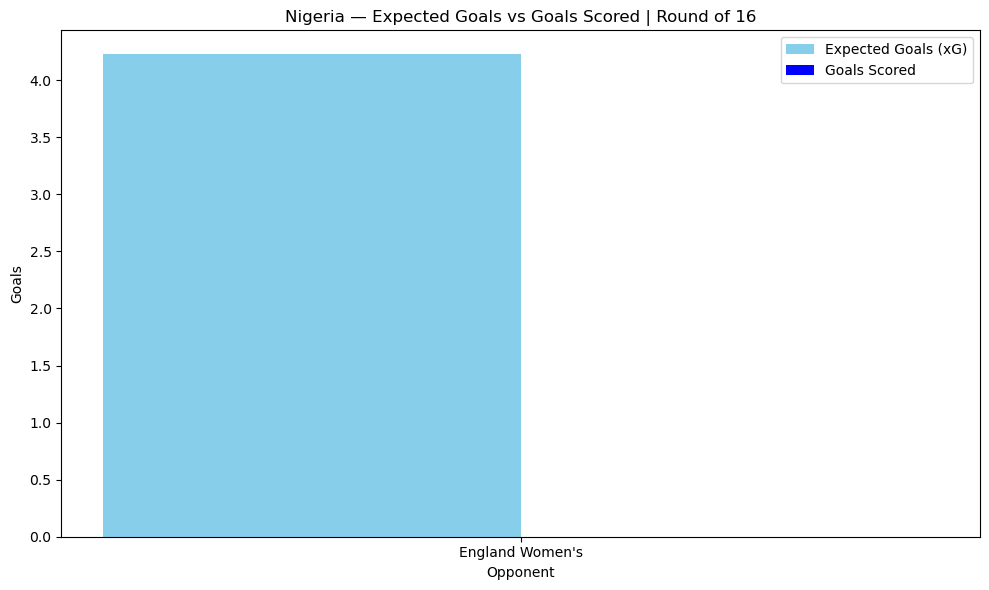

In [28]:
r16 = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Nigeria Women's") &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()

r16["match_date"] = pd.to_datetime(r16["match_date"])

r16 = r16.sort_values("match_date")

x = np.arange(len(r16))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    r16["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    r16["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    r16["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Nigeria — Expected Goals vs Goals Scored | Round of 16")

plt.legend()

plt.tight_layout()
plt.show()

According to the charts presented, both teams were tied at the end of regulation time. Since this is a “knockout” round, the match went to a penalty shootout, which England won 4–2. 
The xG was quite high for both teams and very similar, which may have contributed to the tie. However, it should be noted that neither team scored as much as expected.

In [30]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "England Women's") &
        (womens_world_cup_stats["opponent"] == "Nigeria Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Nigeria Women's") &
        (womens_world_cup_stats["opponent"] == "England Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries",
    "Goals from Shots": "goals_from_shots",
    "Own Goals From": "own_goals_for",	
    "Own Goals Against": "own_goals_against",	
    "Goal type": "goal_type"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "England": [
        match.loc[
            match["team"] == "England Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Nigeria": [
        match.loc[
            match["team"] == "Nigeria Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["England", "Nigeria"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["England", "Nigeria"]
].round(1)


# Display table

comparison

,Metric,England,Nigeria
0,Goals,0,0
1,xG,4.668494,4.225217
2,Goals Minus xG,-0.668494,-2.225217
3,Shots,17,23
4,Shots on Target,8,4
5,Saves,2,4
6,Possession %,49.948365,50.051635
7,Pass Accuracy %,78.364566,69.072165
8,Progressive Passes,118.0,86.0
9,Progressive Carries,17.0,12.0


Teams found:
["England Women's" "Nigeria Women's"]


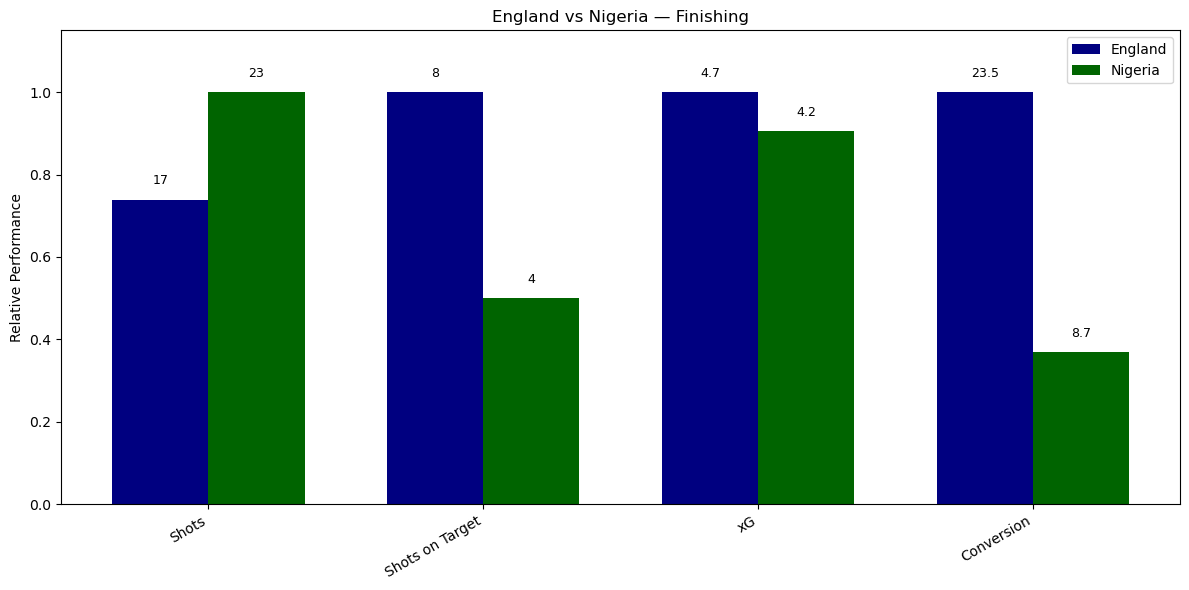

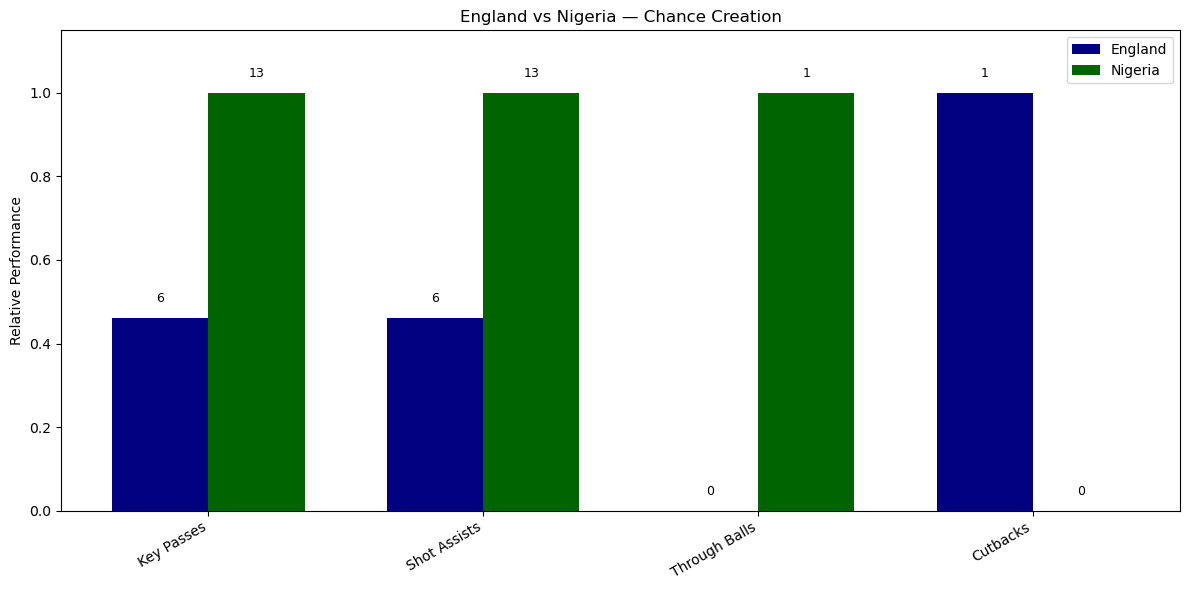

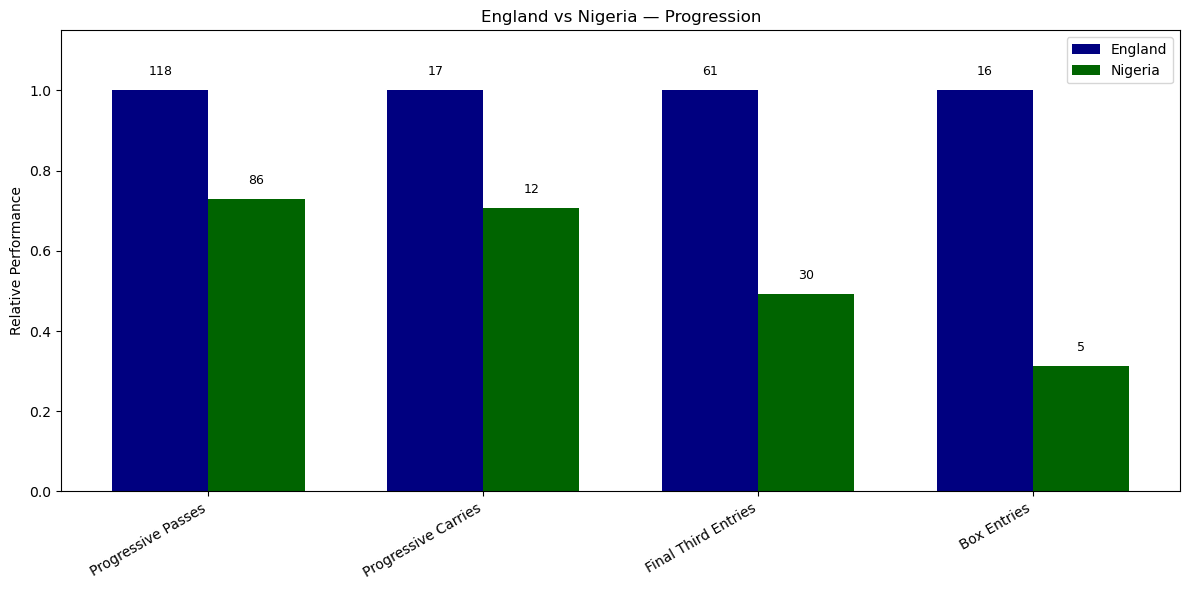

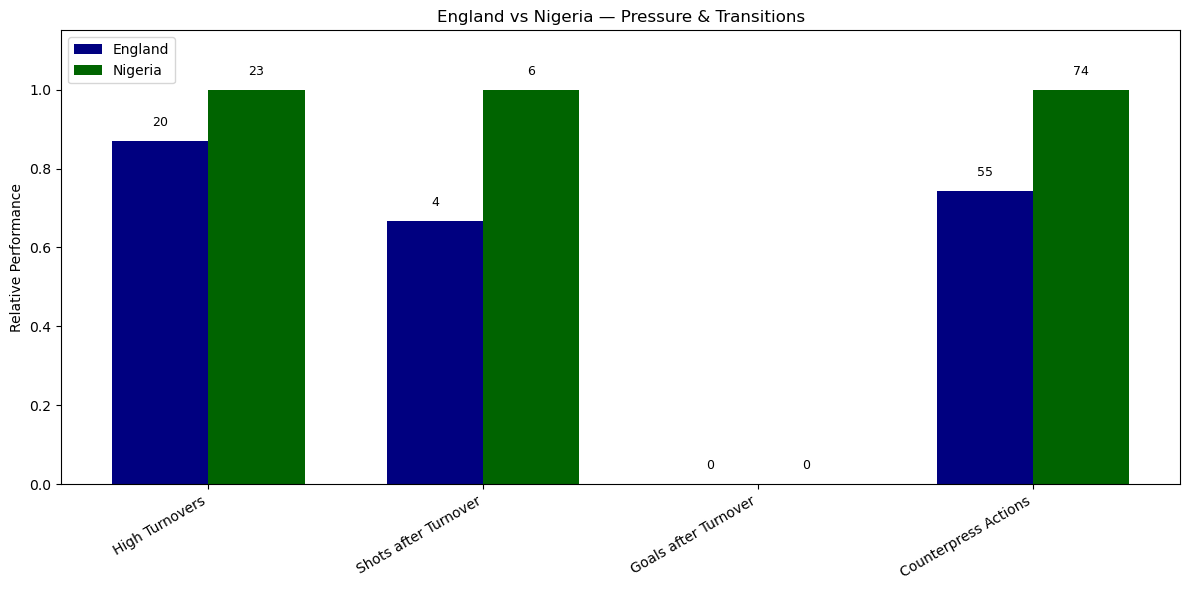

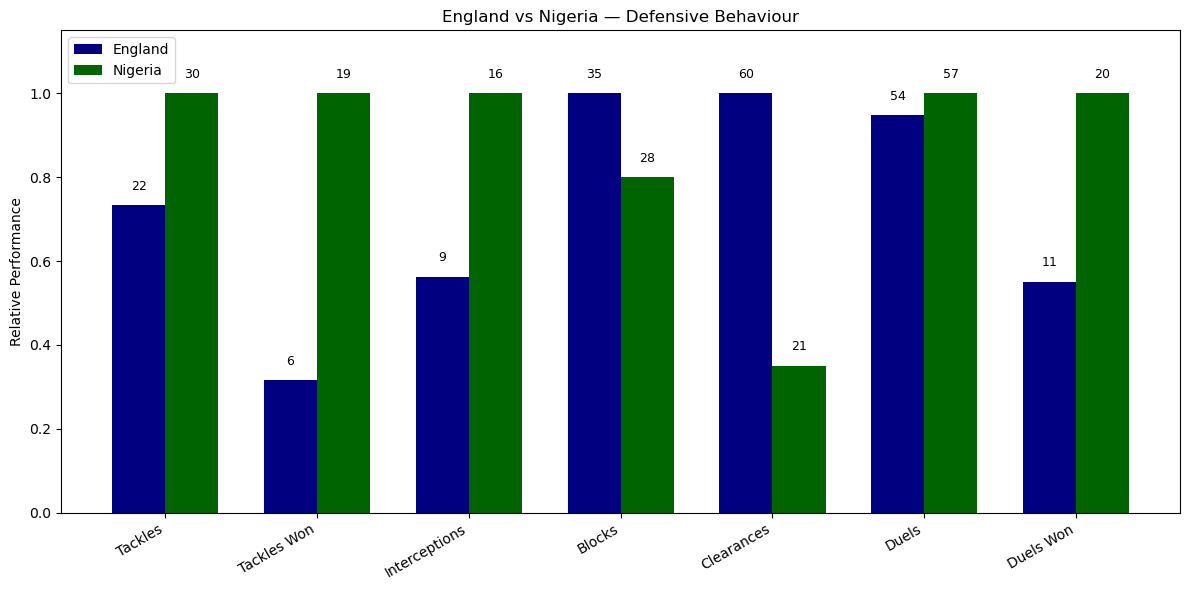

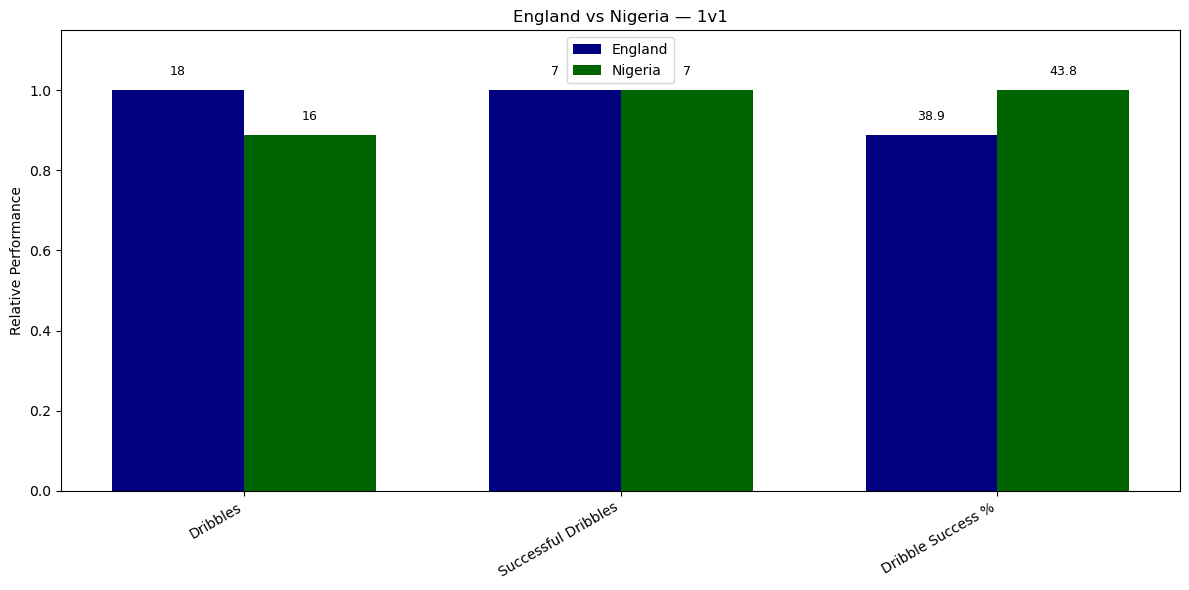

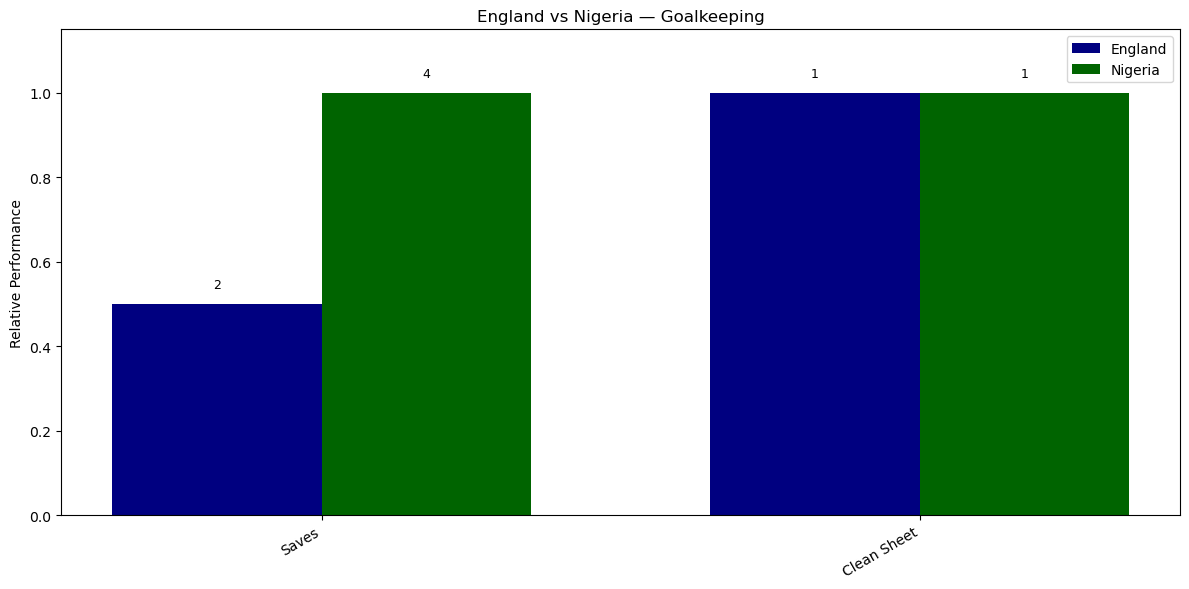

In [32]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (
            (womens_world_cup_stats["team"] == "England Women's") &
            (womens_world_cup_stats["opponent"] == "Nigeria Women's")
        )
        |
        (
            (womens_world_cup_stats["team"] == "Nigeria Women's") &
            (womens_world_cup_stats["opponent"] == "England Women's")
        )
    )
    &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()


# ============================================================
# 2. TEAM NAMES
# ============================================================

team_names = {
    "England": "England Women's",
    "Nigeria": "Nigeria Women's"
}


# ============================================================
# 3. METRICS BY CATEGORY
# ============================================================

categories = {


    "Finishing": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "xG": "xG",
        "Conversion": "conversion_pct"
    },


     "Chance Creation": {
        "Key Passes": "key_passes",
        "Shot Assists": "shot_assists",
        "Through Balls": "through_balls",
        "Cutbacks": "cutbacks"
    },



    "Progression": {
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries"
    },



    "Pressure & Transitions": {
        "High Turnovers": "high_turnovers",
        "Shots after Turnover": "shots_after_turnover",
        "Goals after Turnover": "goals_after_turnover",
        "Counterpress Actions": "counterpress_actions"
    },



    "Defensive Behaviour": {
        "Tackles": "tackles",
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Duels": "duels",
        "Duels Won": "duels_won"
    },



    "1v1": {
        "Dribbles": "dribbles",
        "Successful Dribbles": "successful_dribbles",
        "Dribble Success %": "dribble_success_pct"
    },



    "Goalkeeping": {
        "Saves": "saves",
        "Clean Sheet": "clean_sheet"
    }
}


# ============================================================
# 4. CHECK TEAMS
# ============================================================

print("Teams found:")
print(match["team"].unique())


# ============================================================
# 5. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # --------------------------------------------------------
    # Get real values
    # --------------------------------------------------------

    eng_values = np.array([
        match.loc[
            match["team"] == team_names["England"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)


    nga_values = np.array([
        match.loc[
            match["team"] == team_names["Nigeria"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)


    # --------------------------------------------------------
    # Maximum value for each metric
    # --------------------------------------------------------

    max_values = np.maximum(
        eng_values,
        nga_values
    )


    # --------------------------------------------------------
    # Normalize
    # --------------------------------------------------------

    eng_normalized = np.divide(
        eng_values,
        max_values,
        out=np.zeros_like(eng_values),
        where=max_values != 0
    )


    nga_normalized = np.divide(
        nga_values,
        max_values,
        out=np.zeros_like(nga_values),
        where=max_values != 0
    )


    # --------------------------------------------------------
    # Position of bars
    # --------------------------------------------------------

    x = np.arange(len(metrics))
    width = 0.35


    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    plt.figure(figsize=(12, 6))


    bars_eng = plt.bar(
        x - width / 2,
        eng_normalized,
        width,
        label="England",
        color="navy"
    )


    bars_nga = plt.bar(
        x + width / 2,
        nga_normalized,
        width,
        label="Nigeria",
        color="darkgreen"
    )


    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(
        bars_eng,
        eng_values
    ):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom",
            fontsize=9
        )


    for bar, value in zip(
        bars_nga,
        nga_values
    ):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom",
            fontsize=9
        )


    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"England vs Nigeria — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

In [36]:
match[[
    "team",
    "opponent",
    "formation"
]]

,team,opponent,formation
104,England Women's,Nigeria Women's,3-4-1-2
105,Nigeria Women's,England Women's,4-2-3-1


In [38]:
formation_comparison = pd.DataFrame({
    "Metric": [
        "Formation",
        "Possession %",
        "Shots",
        "xG",
        "Progressive Passes",
        "Progressive Carries",
        "Final Third Entries",
        "Box Entries",
        "High Turnovers",
        "Interceptions",
        "Clearances"
    ],

    "England": [
        match.loc[
            match["team"] == "England Women's",
            "formation"
        ].iloc[0],
        
        match.loc[
            match["team"] == "England Women's",
            "possession_pct"
        ].iloc[0],
        
        match.loc[
            match["team"] == "England Women's",
            "shots"
        ].iloc[0],
        
        match.loc[
            match["team"] == "England Women's",
            "xG"
        ].iloc[0],
        
        match.loc[
            match["team"] == "England Women's",
            "progressive_passes"
        ].iloc[0],
        
        match.loc[
            match["team"] == "England Women's",
            "progressive_carries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "England Women's",
            "final_third_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "England Women's",
            "box_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "England Women's",
            "high_turnovers"
        ].iloc[0],
        
        match.loc[
            match["team"] == "England Women's",
            "interceptions"
        ].iloc[0],
        
        match.loc[
            match["team"] == "England Women's",
            "clearances"
        ].iloc[0]
    ],

    "Nigeria": [
        match.loc[
            match["team"] == "Nigeria Women's",
            "formation"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Nigeria Women's",
            "possession_pct"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Nigeria Women's",
            "shots"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Nigeria Women's",
            "xG"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Nigeria Women's",
            "progressive_passes"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Nigeria Women's",
            "progressive_carries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Nigeria Women's",
            "final_third_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Nigeria Women's",
            "box_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Nigeria Women's",
            "high_turnovers"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Nigeria Women's",
            "interceptions"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Nigeria Women's",
            "clearances"
        ].iloc[0]
    ]
})

# Arredondar percentagens e xG
formation_comparison.loc[
    formation_comparison["Metric"].isin(
        ["Possession %", "xG"]
    ),
    ["England", "Nigeria"]
] = formation_comparison.loc[
    formation_comparison["Metric"].isin(
        ["Possession %", "xG"]
    ),
    ["England", "Nigeria"]
].round(1)

formation_comparison

,Metric,England,Nigeria
0,Formation,3-4-1-2,4-2-3-1
1,Possession %,49.948365,50.051635
2,Shots,17,23
3,xG,4.668494,4.225217
4,Progressive Passes,118.0,86.0
5,Progressive Carries,17.0,12.0
6,Final Third Entries,61.0,30.0
7,Box Entries,16.0,5.0
8,High Turnovers,20.0,23.0
9,Interceptions,9,16


## Conclusion ENG-NGA

Strategically, England and Nigeria adopted different approaches. England, in a 3-4-1-2, focused on structured possession and progressing the ball, recording more entries into the final third and penalty area. Nigeria, in a 4-2-3-1, was more aggressive without the ball, using high pressing, turnovers and counterpressing to regain possession quickly. Despite England’s greater territorial control and attacking progression, Nigeria created opportunities through key passes and shot assists. Overall, it was a balanced game, with both teams showing strengths in different areas and the 0–0 reflecting their defensive effectiveness.

# GAME ANALYSIS AUS-DEN

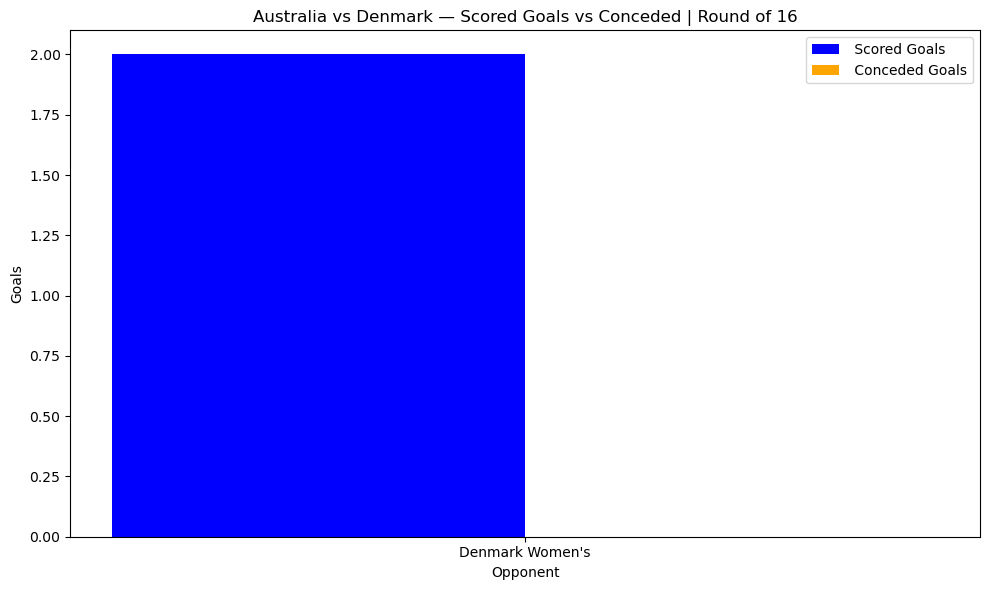

In [44]:
r16 = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Australia Women's") &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()

r16["match_date"] = pd.to_datetime(r16["match_date"])

r16 = r16.sort_values("match_date")

x = np.arange(len(r16))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    r16["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    r16["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    r16["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Australia vs Denmark — Scored Goals vs Conceded | Round of 16")

plt.legend()

plt.tight_layout()
plt.show()

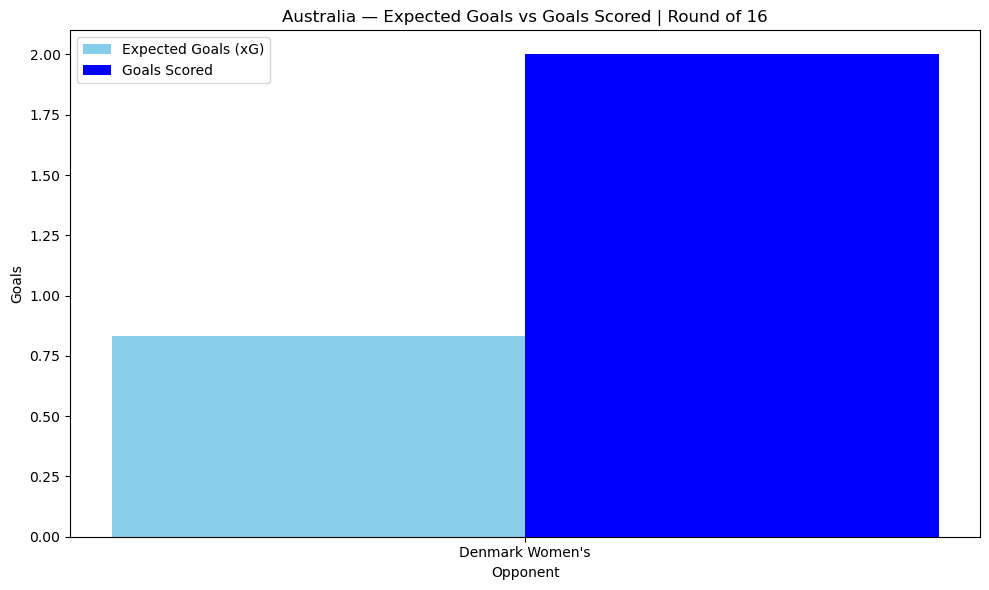

In [46]:
r16 = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Australia Women's") &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()

r16["match_date"] = pd.to_datetime(r16["match_date"])

r16 = r16.sort_values("match_date")

x = np.arange(len(r16))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    r16["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    r16["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    r16["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Australia — Expected Goals vs Goals Scored | Round of 16")

plt.legend()

plt.tight_layout()
plt.show()

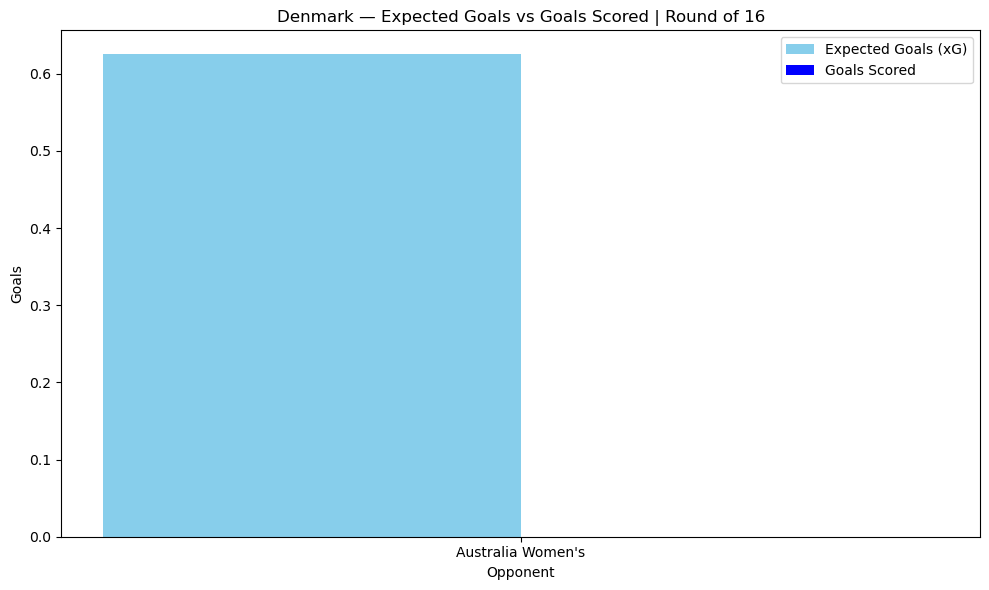

In [48]:
r16 = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Denmark Women's") &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()

r16["match_date"] = pd.to_datetime(r16["match_date"])

r16 = r16.sort_values("match_date")

x = np.arange(len(r16))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    r16["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    r16["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    r16["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Denmark — Expected Goals vs Goals Scored | Round of 16")

plt.legend()

plt.tight_layout()
plt.show()

Australia won its Round of 16 match, posting an xG lower than the actual number of goals scored. <br>
- xG: 0.83
- Goals: 2
<br>

This indicates superiority in finishing and in creating scoring opportunities. 
Denmark, on the other hand, with a similar xG—0.62—did not score any goals, falling short of expectations. This may reflect a lack of finishing or superior defense on the part of the opponent.

In [50]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Australia Women's") &
        (womens_world_cup_stats["opponent"] == "Denmark Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Denmark Women's") &
        (womens_world_cup_stats["opponent"] == "Australia Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries",
    "Goals from Shots": "goals_from_shots",
    "Own Goals From": "own_goals_for",	
    "Own Goals Against": "own_goals_against",	
    "Goal type": "goal_type"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Australia": [
        match.loc[
            match["team"] == "Australia Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Denmark": [
        match.loc[
            match["team"] == "Denmark Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Australia", "Denmark"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Australia", "Denmark"]
].round(1)


# Display table

comparison

,Metric,Australia,Denmark
0,Goals,2,0
1,xG,0.834424,0.624866
2,Goals Minus xG,1.165576,-0.624866
3,Shots,10,13
4,Shots on Target,3,3
5,Saves,3,1
6,Possession %,45.9708,54.0292
7,Pass Accuracy %,69.471154,75.37037
8,Progressive Passes,106.0,111.0
9,Progressive Carries,19.0,19.0


Teams found:
["Australia Women's" "Denmark Women's"]


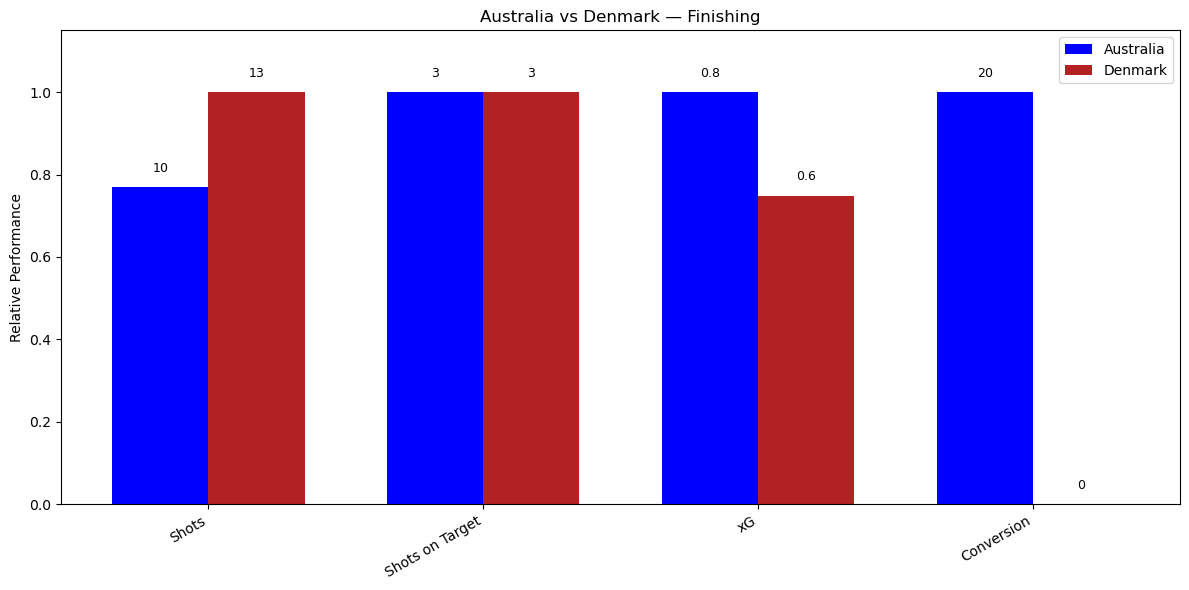

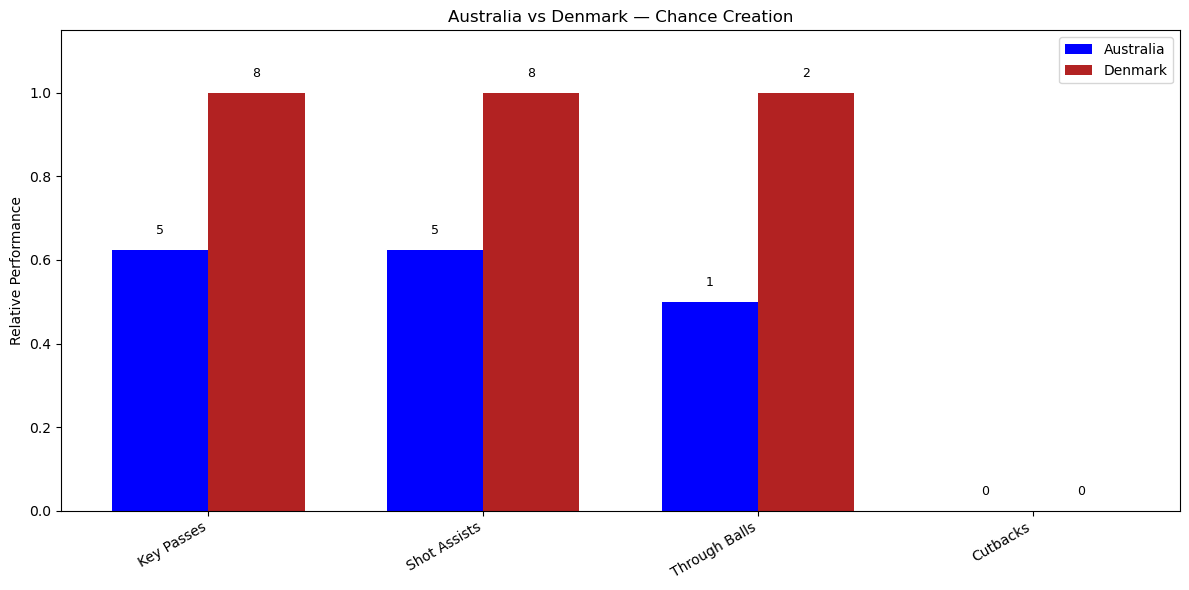

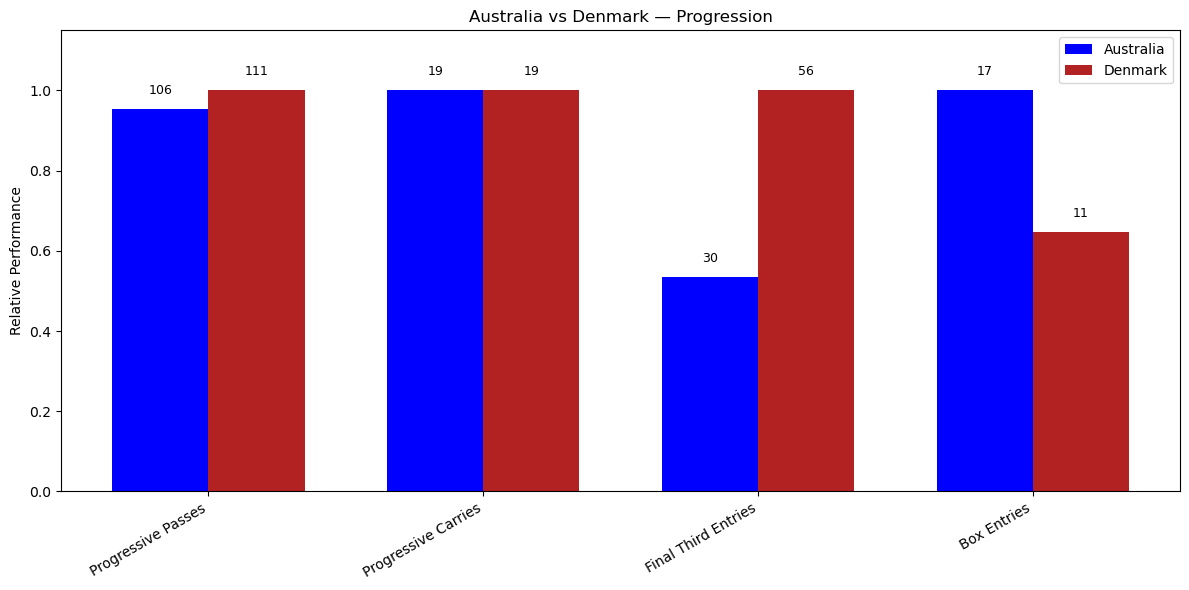

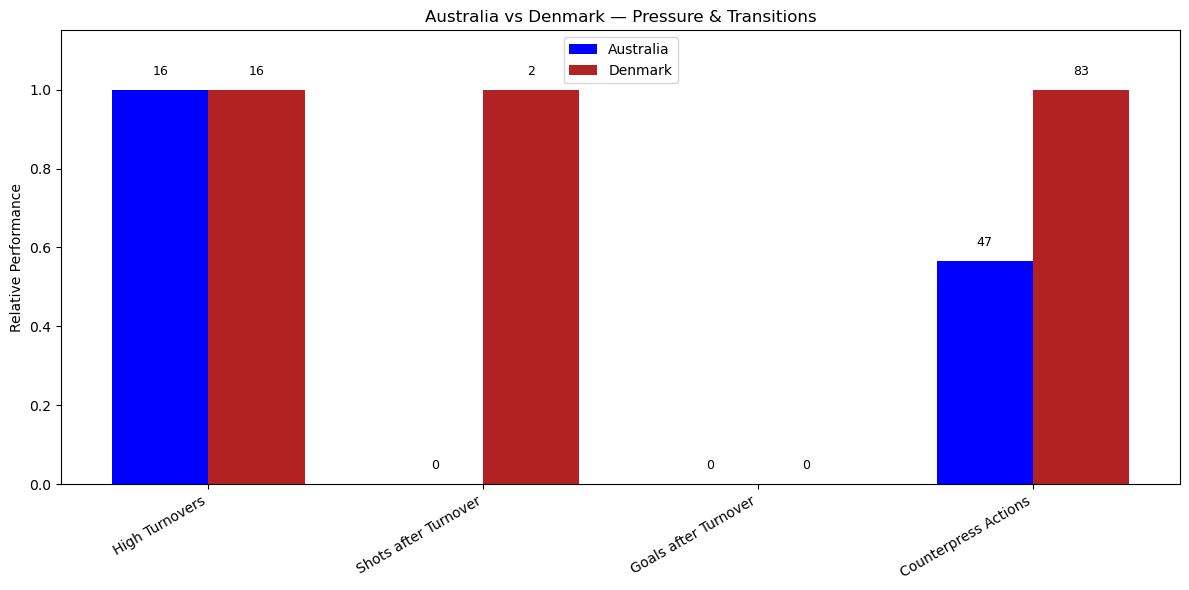

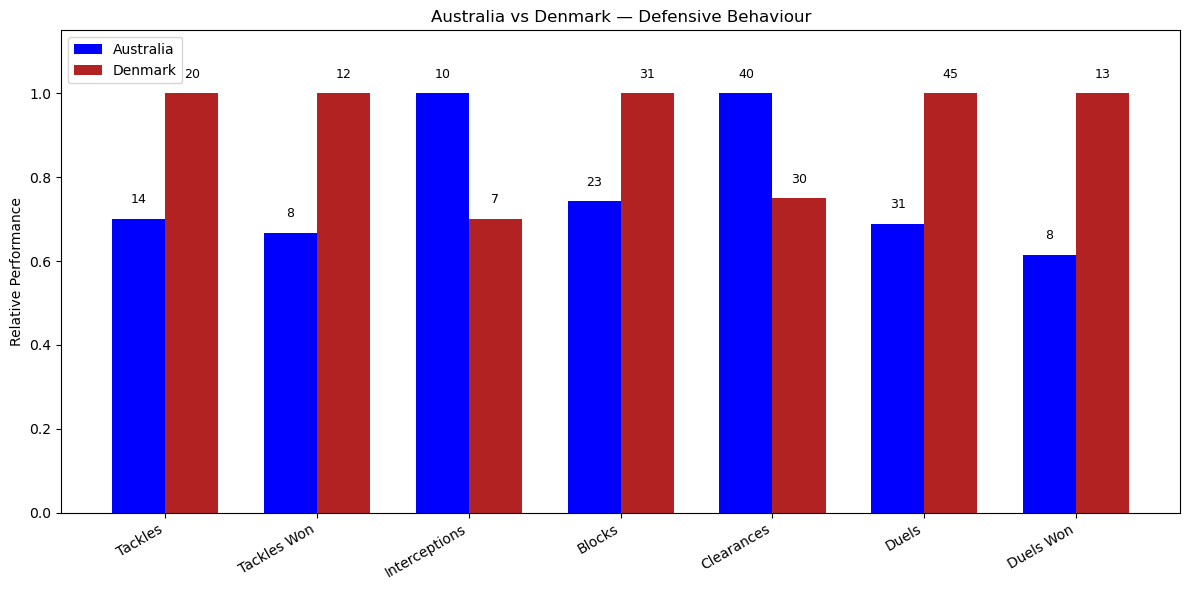

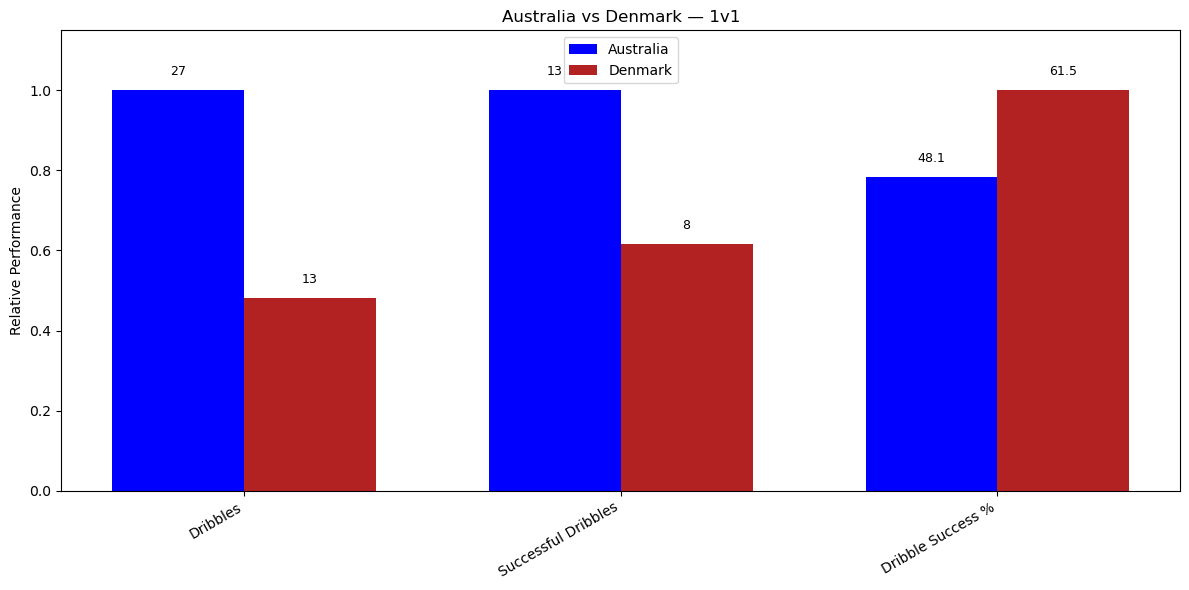

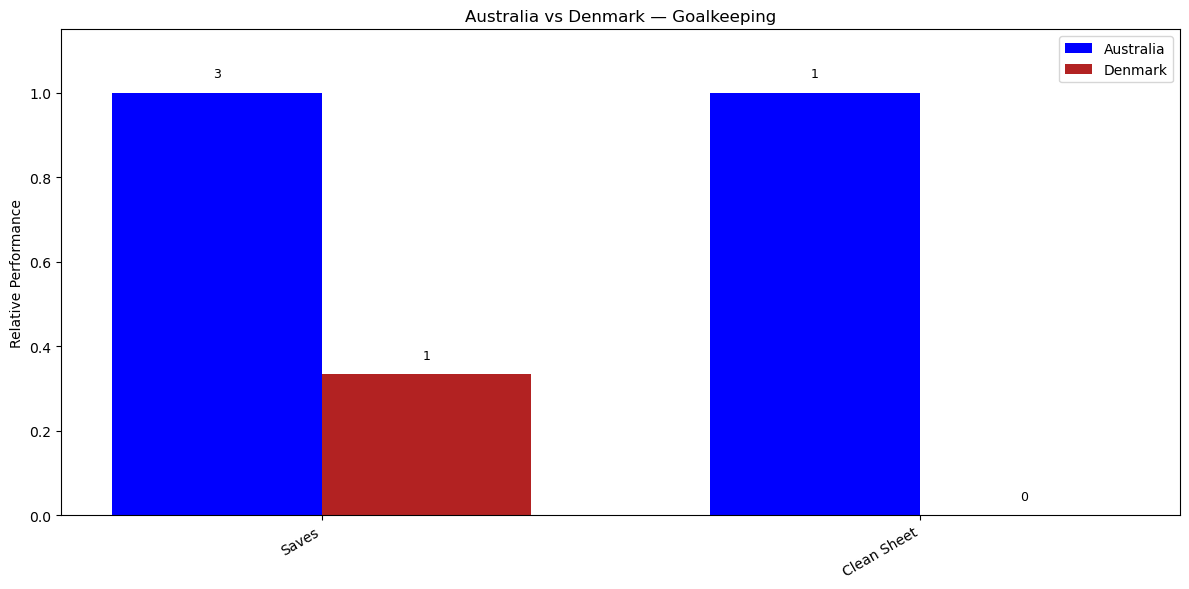

In [52]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Australia Women's") &
        (womens_world_cup_stats["opponent"] == "Denmark Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Denmark Women's") &
        (womens_world_cup_stats["opponent"] == "Australia Women's")
    )
    &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()


# ============================================================
# 2. TEAM NAMES
# ============================================================

team_names = {
    "Australia": "Australia Women's",
    "Denmark": "Denmark Women's"
}


# ============================================================
# 3. METRICS BY CATEGORY
# ============================================================

categories = {


    "Finishing": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "xG": "xG",
        "Conversion": "conversion_pct"
    },


     "Chance Creation": {
        "Key Passes": "key_passes",
        "Shot Assists": "shot_assists",
        "Through Balls": "through_balls",
        "Cutbacks": "cutbacks"
    },



    "Progression": {
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries"
    },



    "Pressure & Transitions": {
        "High Turnovers": "high_turnovers",
        "Shots after Turnover": "shots_after_turnover",
        "Goals after Turnover": "goals_after_turnover",
        "Counterpress Actions": "counterpress_actions"
    },



    "Defensive Behaviour": {
        "Tackles": "tackles",
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Duels": "duels",
        "Duels Won": "duels_won"
    },



    "1v1": {
        "Dribbles": "dribbles",
        "Successful Dribbles": "successful_dribbles",
        "Dribble Success %": "dribble_success_pct"
    },



    "Goalkeeping": {
        "Saves": "saves",
        "Clean Sheet": "clean_sheet"
    }
}


# ============================================================
# 4. CHECK TEAMS
# ============================================================

print("Teams found:")
print(match["team"].unique())


# ============================================================
# 5. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # --------------------------------------------------------
    # Get real values
    # --------------------------------------------------------

    aus_values = np.array([
        match.loc[
            match["team"] == team_names["Australia"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)


    den_values = np.array([
        match.loc[
            match["team"] == team_names["Denmark"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)


    # --------------------------------------------------------
    # Maximum value for each metric
    # --------------------------------------------------------

    max_values = np.maximum(
        aus_values,
        den_values
    )


    # --------------------------------------------------------
    # Normalize
    # --------------------------------------------------------

    aus_normalized = np.divide(
        aus_values,
        max_values,
        out=np.zeros_like(aus_values),
        where=max_values != 0
    )


    den_normalized = np.divide(
        den_values,
        max_values,
        out=np.zeros_like(den_values),
        where=max_values != 0
    )


    # --------------------------------------------------------
    # Position of bars
    # --------------------------------------------------------

    x = np.arange(len(metrics))
    width = 0.35


    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    plt.figure(figsize=(12, 6))


    bars_aus = plt.bar(
        x - width / 2,
        aus_normalized,
        width,
        label="Australia",
        color="blue"
    )


    bars_den = plt.bar(
        x + width / 2,
        den_normalized,
        width,
        label="Denmark",
        color="firebrick"
    )


    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(
        bars_aus,
        aus_values
    ):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom",
            fontsize=9
        )


    for bar, value in zip(
        bars_den,
        den_values
    ):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom",
            fontsize=9
        )


    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Australia vs Denmark — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

In [54]:
match[[
    "team",
    "opponent",
    "formation"
]]

,team,opponent,formation
106,Australia Women's,Denmark Women's,4-4-2
107,Denmark Women's,Australia Women's,4-2-3-1


In [58]:
formation_comparison = pd.DataFrame({
    "Metric": [
        "Formation",
        "Possession %",
        "Shots",
        "xG",
        "Progressive Passes",
        "Progressive Carries",
        "Final Third Entries",
        "Box Entries",
        "High Turnovers",
        "Interceptions",
        "Clearances"
    ],

    "Australia": [
        match.loc[
            match["team"] == "Australia Women's",
            "formation"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Australia Women's",
            "possession_pct"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Australia Women's",
            "shots"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Australia Women's",
            "xG"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Australia Women's",
            "progressive_passes"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Australia Women's",
            "progressive_carries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Australia Women's",
            "final_third_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Australia Women's",
            "box_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Australia Women's",
            "high_turnovers"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Australia Women's",
            "interceptions"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Australia Women's",
            "clearances"
        ].iloc[0]
    ],

    "Denmark": [
        match.loc[
            match["team"] == "Denmark Women's",
            "formation"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Denmark Women's",
            "possession_pct"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Denmark Women's",
            "shots"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Denmark Women's",
            "xG"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Denmark Women's",
            "progressive_passes"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Denmark Women's",
            "progressive_carries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Denmark Women's",
            "final_third_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Denmark Women's",
            "box_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Denmark Women's",
            "high_turnovers"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Denmark Women's",
            "interceptions"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Denmark Women's",
            "clearances"
        ].iloc[0]
    ]
})

# Arredondar percentagens e xG
formation_comparison.loc[
    formation_comparison["Metric"].isin(
        ["Possession %", "xG"]
    ),
    ["Australia", "Denmark"]
] = formation_comparison.loc[
    formation_comparison["Metric"].isin(
        ["Possession %", "xG"]
    ),
    ["Australia", "Denmark"]
].round(1)

formation_comparison

,Metric,Australia,Denmark
0,Formation,4-4-2,4-2-3-1
1,Possession %,45.9708,54.0292
2,Shots,10,13
3,xG,0.834424,0.624866
4,Progressive Passes,106.0,111.0
5,Progressive Carries,19.0,19.0
6,Final Third Entries,30.0,56.0
7,Box Entries,17.0,11.0
8,High Turnovers,16.0,16.0
9,Interceptions,10,7


## Conclusion AUS-DEN

Strategically, Denmark, in a 4-2-3-1, recorded higher values across most key metrics, particularly in possession, progression and attacking activity. Australia, in a 4-4-2, adopted a more direct and efficient approach, creating fewer opportunities but making the most of them, scoring twice from a lower xG. Denmark had more possession, territorial control and shots, but failed to convert its chances and conceded two goals. The goalkeepers also played different roles, contributing to the contrasting outcomes. Overall, the match highlights that statistical dominance does not always translate into effectiveness, especially in decisive moments.

# GAME ANALYSIS COL-JAM

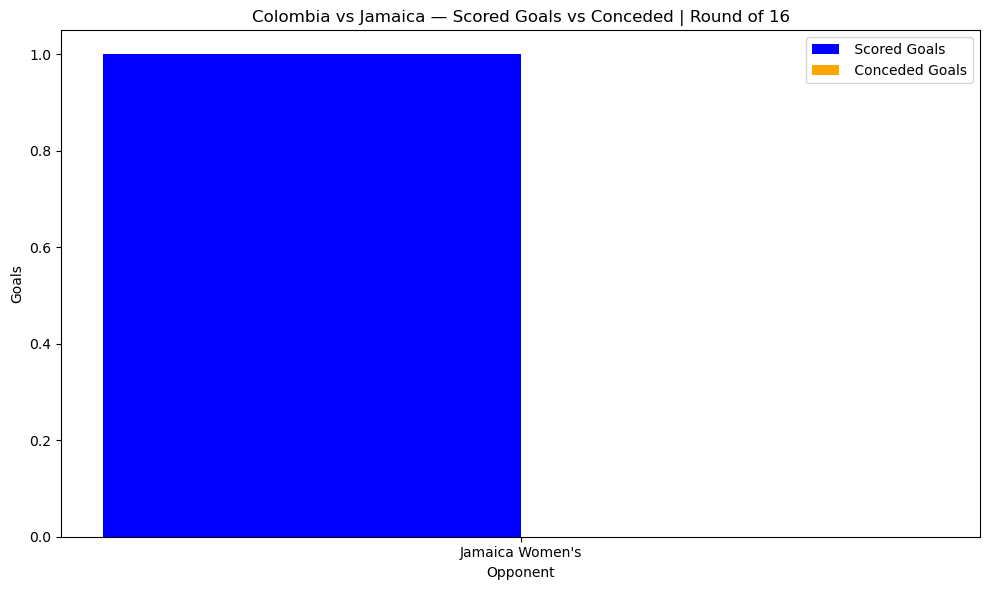

In [65]:
r16 = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Colombia Women's") &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()

r16["match_date"] = pd.to_datetime(r16["match_date"])

r16 = r16.sort_values("match_date")

x = np.arange(len(r16))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    r16["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    r16["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    r16["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Colombia vs Jamaica — Scored Goals vs Conceded | Round of 16")

plt.legend()

plt.tight_layout()
plt.show()

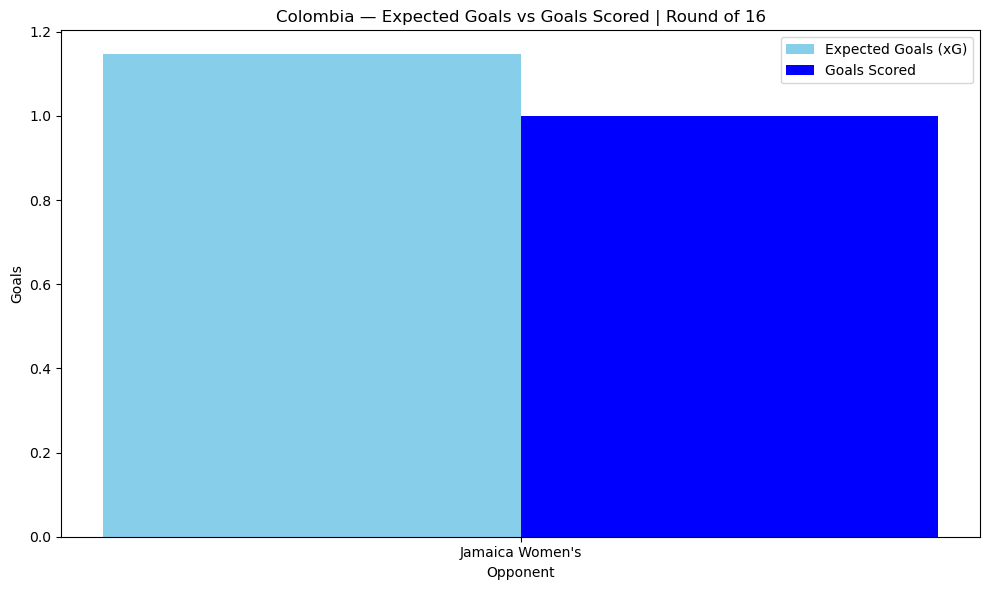

In [67]:
r16 = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Colombia Women's") &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()

r16["match_date"] = pd.to_datetime(r16["match_date"])

r16 = r16.sort_values("match_date")

x = np.arange(len(r16))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    r16["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    r16["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    r16["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Colombia — Expected Goals vs Goals Scored | Round of 16")

plt.legend()

plt.tight_layout()
plt.show()

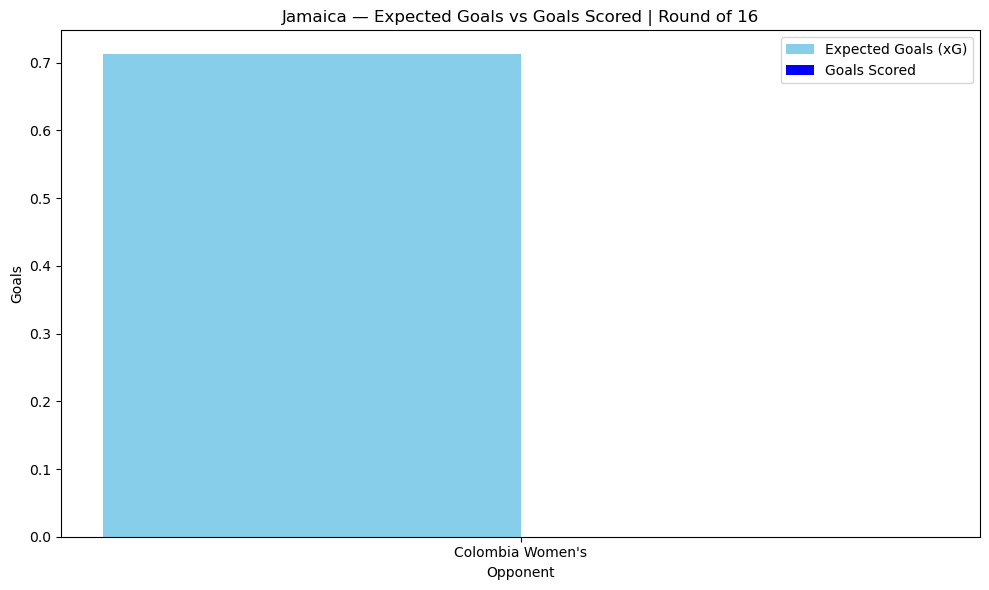

In [69]:
r16 = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Jamaica Women's") &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()

r16["match_date"] = pd.to_datetime(r16["match_date"])

r16 = r16.sort_values("match_date")

x = np.arange(len(r16))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    r16["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    r16["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    r16["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Jamaica — Expected Goals vs Goals Scored | Round of 16")

plt.legend()

plt.tight_layout()
plt.show()

Colombia won this match against Jamaica; however, the South American team underperformed in terms of finishing and efficiency relative to xG.
Jamaica, meanwhile, suffered the same fate as Colombia, failing to score a single goal. 

In [71]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Colombia Women's") &
        (womens_world_cup_stats["opponent"] == "Jamaica Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Jamaica Women's") &
        (womens_world_cup_stats["opponent"] == "Colombia Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries",
    "Goals from Shots": "goals_from_shots",
    "Own Goals From": "own_goals_for",	
    "Own Goals Against": "own_goals_against",	
    "Goal type": "goal_type"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Colombia": [
        match.loc[
            match["team"] == "Colombia Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Jamaica": [
        match.loc[
            match["team"] == "Jamaica Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Colombia", "Jamaica"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Colombia", "Jamaica"]
].round(1)


# Display table

comparison

,Metric,Colombia,Jamaica
0,Goals,1,0
1,xG,1.145913,0.712324
2,Goals Minus xG,-0.145913,-0.712324
3,Shots,11,6
4,Shots on Target,3,2
5,Saves,2,2
6,Possession %,47.040051,52.959949
7,Pass Accuracy %,67.204301,65.616798
8,Progressive Passes,80.0,82.0
9,Progressive Carries,12.0,10.0


Teams found:
["Colombia Women's" "Jamaica Women's"]


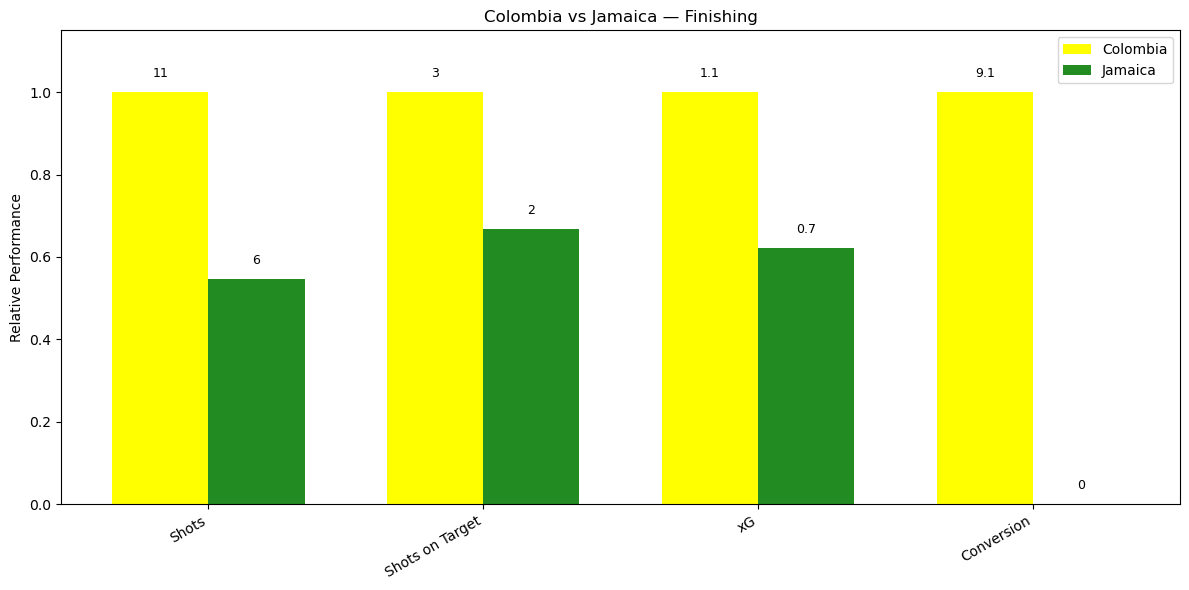

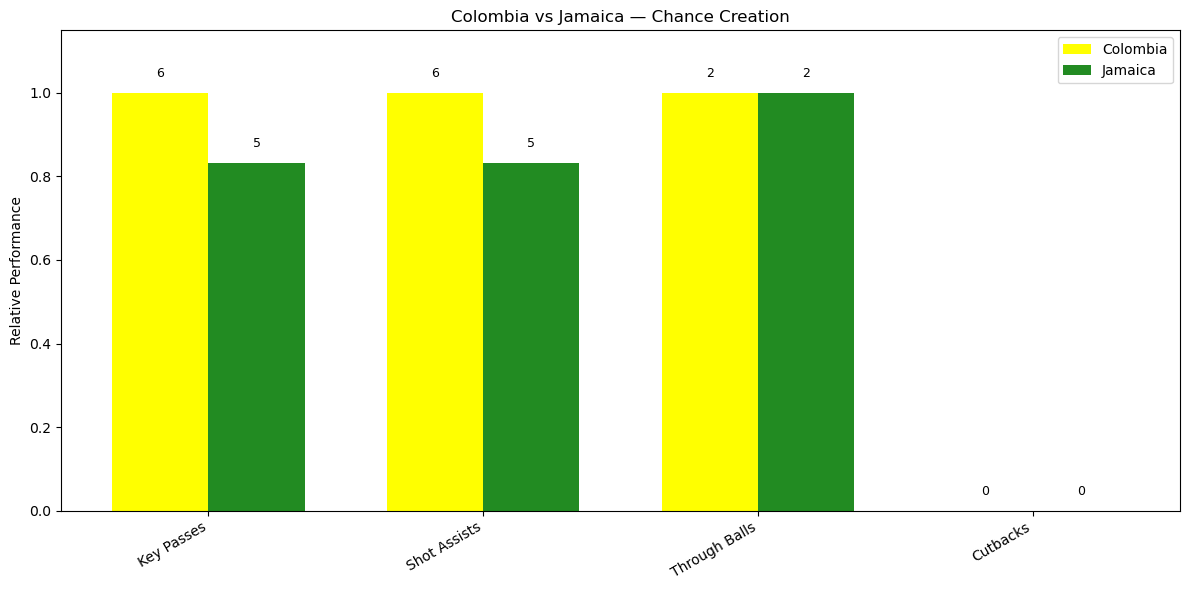

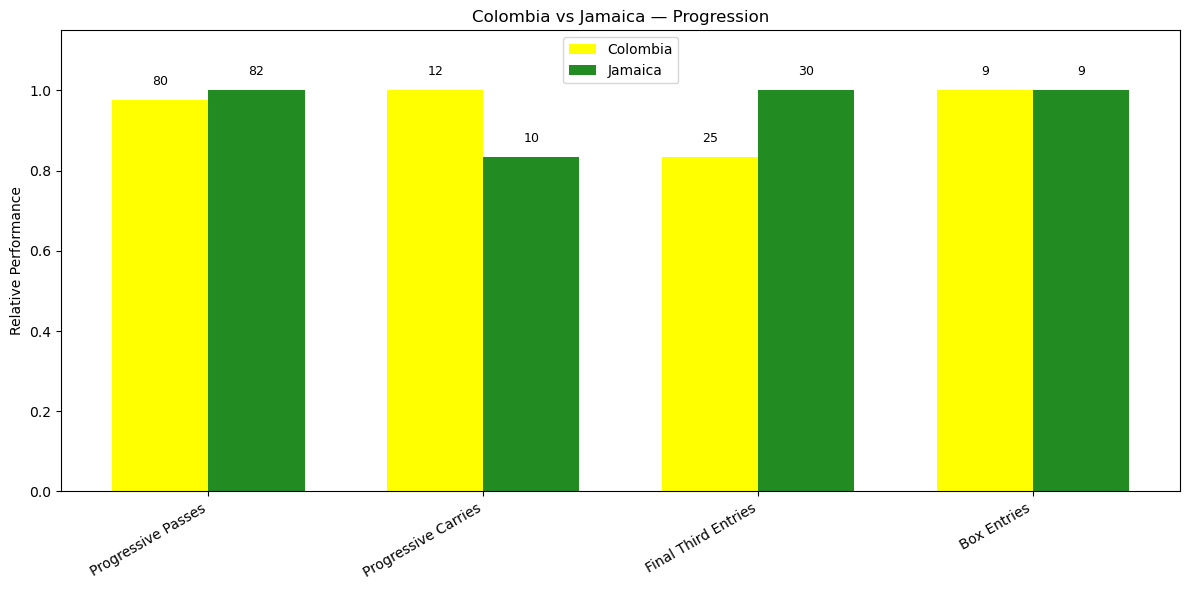

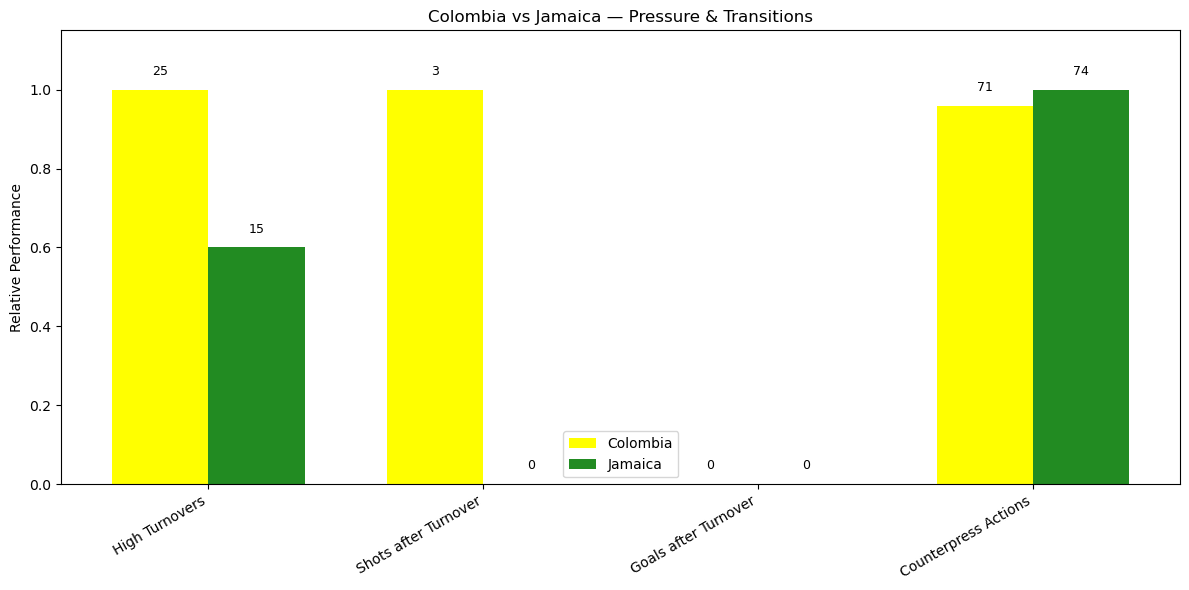

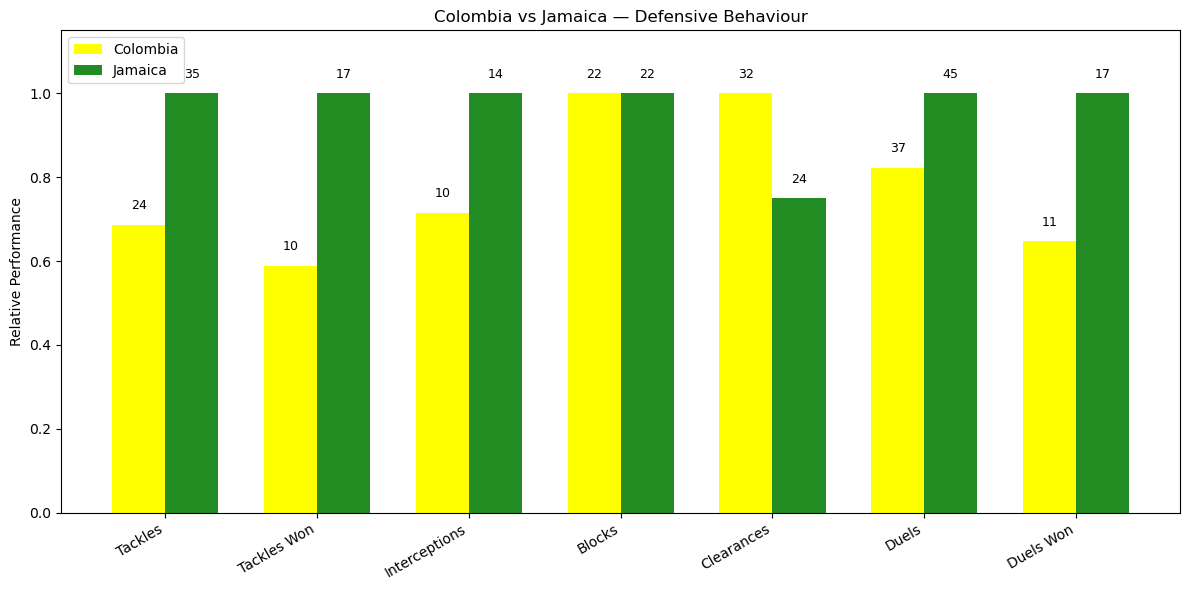

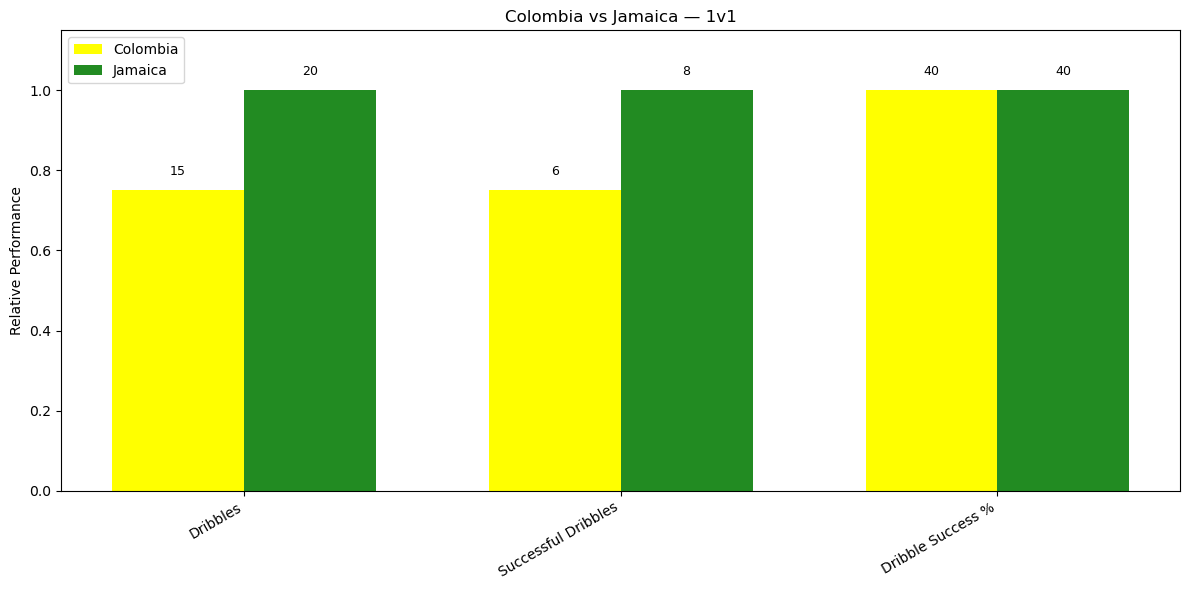

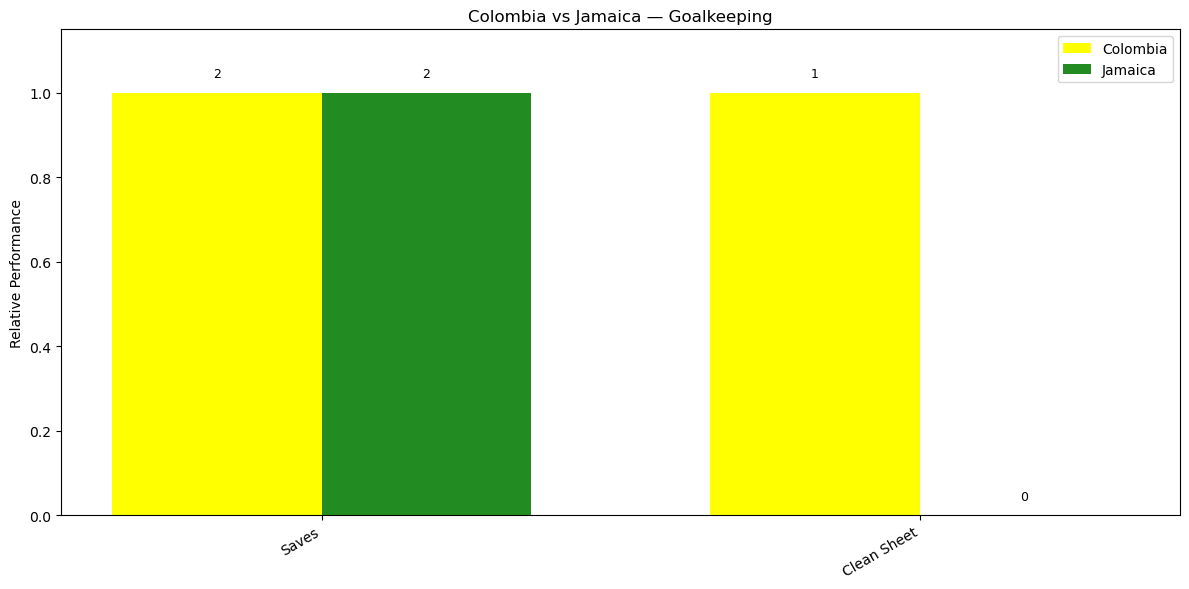

In [73]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Colombia Women's") &
        (womens_world_cup_stats["opponent"] == "Jamaica Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Jamaica Women's") &
        (womens_world_cup_stats["opponent"] == "Colombia Women's")
    )
    &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()


# ============================================================
# 2. TEAM NAMES
# ============================================================

team_names = {
    "Colombia": "Colombia Women's",
    "Jamaica": "Jamaica Women's"
}


# ============================================================
# 3. METRICS BY CATEGORY
# ============================================================

categories = {


    "Finishing": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "xG": "xG",
        "Conversion": "conversion_pct"
    },


     "Chance Creation": {
        "Key Passes": "key_passes",
        "Shot Assists": "shot_assists",
        "Through Balls": "through_balls",
        "Cutbacks": "cutbacks"
    },



    "Progression": {
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries"
    },



    "Pressure & Transitions": {
        "High Turnovers": "high_turnovers",
        "Shots after Turnover": "shots_after_turnover",
        "Goals after Turnover": "goals_after_turnover",
        "Counterpress Actions": "counterpress_actions"
    },



    "Defensive Behaviour": {
        "Tackles": "tackles",
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Duels": "duels",
        "Duels Won": "duels_won"
    },



    "1v1": {
        "Dribbles": "dribbles",
        "Successful Dribbles": "successful_dribbles",
        "Dribble Success %": "dribble_success_pct"
    },



    "Goalkeeping": {
        "Saves": "saves",
        "Clean Sheet": "clean_sheet"
    }
}


# ============================================================
# 4. CHECK TEAMS
# ============================================================

print("Teams found:")
print(match["team"].unique())


# ============================================================
# 5. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # --------------------------------------------------------
    # Get real values
    # --------------------------------------------------------

    col_values = np.array([
        match.loc[
            match["team"] == team_names["Colombia"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)


    jam_values = np.array([
        match.loc[
            match["team"] == team_names["Jamaica"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)


    # --------------------------------------------------------
    # Maximum value for each metric
    # --------------------------------------------------------

    max_values = np.maximum(
        col_values,
        jam_values
    )


    # --------------------------------------------------------
    # Normalize
    # --------------------------------------------------------

    col_normalized = np.divide(
        col_values,
        max_values,
        out=np.zeros_like(col_values),
        where=max_values != 0
    )


    jam_normalized = np.divide(
        jam_values,
        max_values,
        out=np.zeros_like(jam_values),
        where=max_values != 0
    )


    # --------------------------------------------------------
    # Position of bars
    # --------------------------------------------------------

    x = np.arange(len(metrics))
    width = 0.35


    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    plt.figure(figsize=(12, 6))


    bars_col = plt.bar(
        x - width / 2,
        col_normalized,
        width,
        label="Colombia",
        color="yellow"
    )


    bars_jam = plt.bar(
        x + width / 2,
        jam_normalized,
        width,
        label="Jamaica",
        color="forestgreen"
    )


    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(
        bars_col,
        col_values
    ):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom",
            fontsize=9
        )


    for bar, value in zip(
        bars_jam,
        jam_values
    ):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom",
            fontsize=9
        )


    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Colombia vs Jamaica — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

In [75]:
match[[
    "team",
    "opponent",
    "formation"
]]

,team,opponent,formation
108,Colombia Women's,Jamaica Women's,4-2-3-1
109,Jamaica Women's,Colombia Women's,4-2-3-1


In [77]:
formation_comparison = pd.DataFrame({
    "Metric": [
        "Formation",
        "Possession %",
        "Shots",
        "xG",
        "Progressive Passes",
        "Progressive Carries",
        "Final Third Entries",
        "Box Entries",
        "High Turnovers",
        "Interceptions",
        "Clearances"
    ],

    "Colombia": [
        match.loc[
            match["team"] == "Colombia Women's",
            "formation"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Colombia Women's",
            "possession_pct"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Colombia Women's",
            "shots"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Colombia Women's",
            "xG"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Colombia Women's",
            "progressive_passes"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Colombia Women's",
            "progressive_carries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Colombia Women's",
            "final_third_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Colombia Women's",
            "box_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Colombia Women's",
            "high_turnovers"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Colombia Women's",
            "interceptions"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Colombia Women's",
            "clearances"
        ].iloc[0]
    ],

    "Jamaica": [
        match.loc[
            match["team"] == "Jamaica Women's",
            "formation"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Jamaica Women's",
            "possession_pct"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Jamaica Women's",
            "shots"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Jamaica Women's",
            "xG"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Jamaica Women's",
            "progressive_passes"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Jamaica Women's",
            "progressive_carries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Jamaica Women's",
            "final_third_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Jamaica Women's",
            "box_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Jamaica Women's",
            "high_turnovers"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Jamaica Women's",
            "interceptions"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Jamaica Women's",
            "clearances"
        ].iloc[0]
    ]
})

# Arredondar percentagens e xG
formation_comparison.loc[
    formation_comparison["Metric"].isin(
        ["Possession %", "xG"]
    ),
    ["Colombia", "Jamaica"]
] = formation_comparison.loc[
    formation_comparison["Metric"].isin(
        ["Possession %", "xG"]
    ),
    ["Colombia", "Jamaica"]
].round(1)

formation_comparison

,Metric,Colombia,Jamaica
0,Formation,4-2-3-1,4-2-3-1
1,Possession %,47.040051,52.959949
2,Shots,11,6
3,xG,1.145913,0.712324
4,Progressive Passes,80.0,82.0
5,Progressive Carries,12.0,10.0
6,Final Third Entries,25.0,30.0
7,Box Entries,9.0,9.0
8,High Turnovers,25.0,15.0
9,Interceptions,10,14


## Conclusion COL-JAM

Strategically, both teams used a 4-2-3-1, but with very different approaches. Colombia adopted a more attacking style, dominating progression and creating more chances, with higher shots, xG and high turnovers. Jamaica, on the other hand, was more defensive and aggressive without the ball, recording more tackles won and interceptions despite conceding the only goal. Colombia controlled the attacking phases better, while Jamaica was stronger defensively. However, Colombia’s higher attacking output did not fully translate into efficiency, as they created several chances but still left many opportunities unconverted. This shows how the same formation can be used very differently depending on the team’s strategy and priorities.


# GAME ANALYSIS FRA-MOR

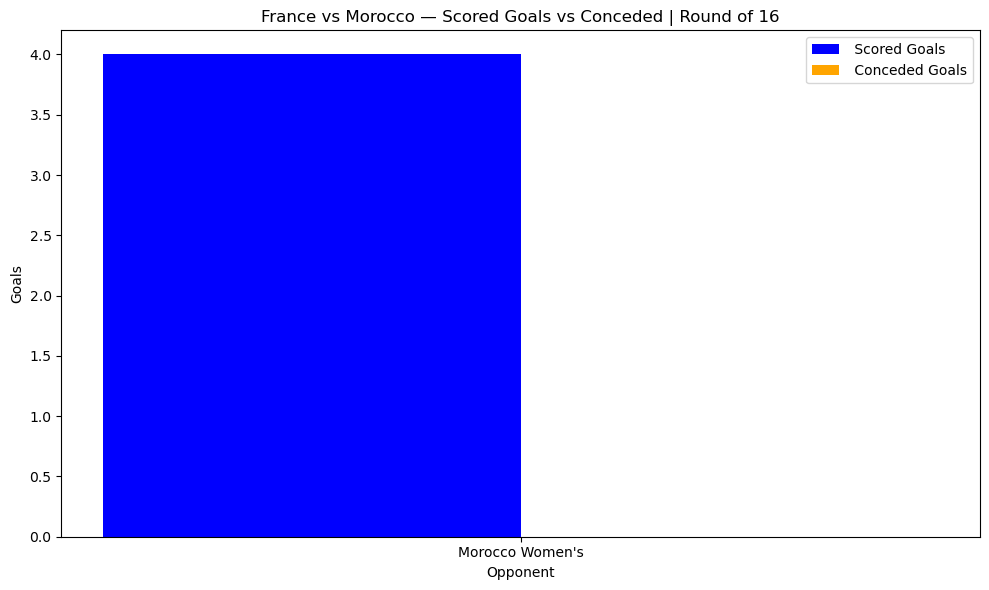

In [84]:
r16 = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "France Women's") &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()

r16["match_date"] = pd.to_datetime(r16["match_date"])

r16 = r16.sort_values("match_date")

x = np.arange(len(r16))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    r16["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    r16["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    r16["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("France vs Morocco — Scored Goals vs Conceded | Round of 16")

plt.legend()

plt.tight_layout()
plt.show()

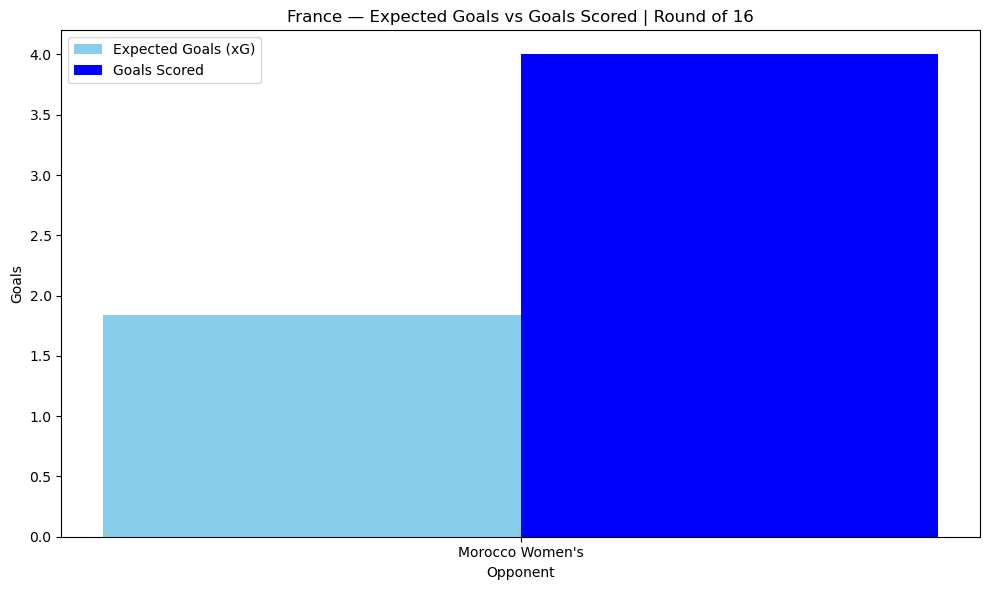

In [86]:
r16 = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "France Women's") &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()

r16["match_date"] = pd.to_datetime(r16["match_date"])

r16 = r16.sort_values("match_date")

x = np.arange(len(r16))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    r16["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    r16["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    r16["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("France — Expected Goals vs Goals Scored | Round of 16")

plt.legend()

plt.tight_layout()
plt.show()

France won the game against Morocco, scoring 4 goals while the North African team failed to score any. What shocks me the most is Morocco’s xG of 0.02—extremely low (perhaps the lowest in the tournament so far). France, on the other hand, exceeded its xG by scoring two more goals than predicted, demonstrating a level of efficiency and dominance that its opponent lacked.

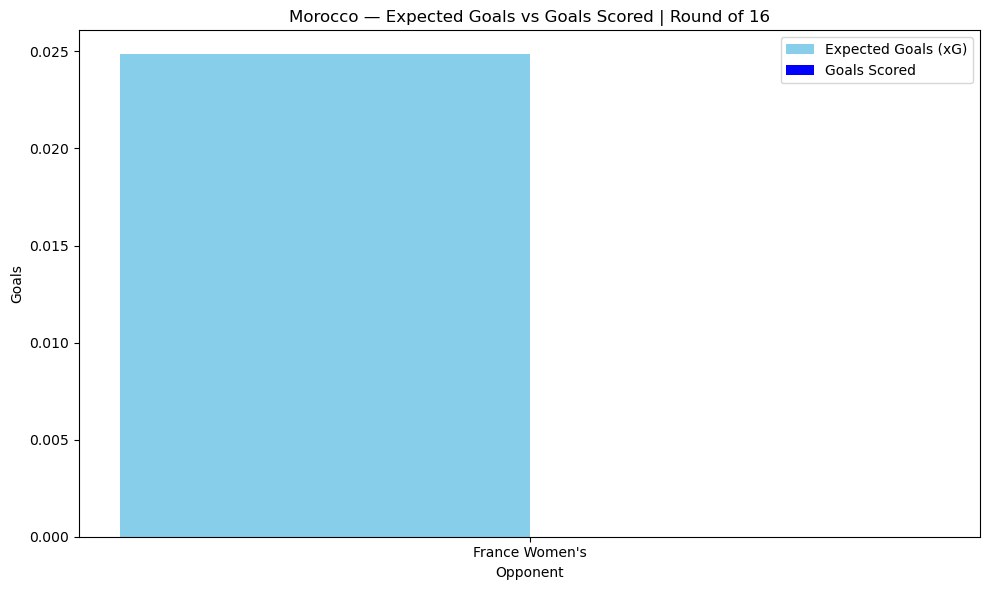

In [88]:
r16 = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Morocco Women's") &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()

r16["match_date"] = pd.to_datetime(r16["match_date"])

r16 = r16.sort_values("match_date")

x = np.arange(len(r16))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    r16["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    r16["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    r16["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Morocco — Expected Goals vs Goals Scored | Round of 16")

plt.legend()

plt.tight_layout()
plt.show()

In [90]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "France Women's") &
        (womens_world_cup_stats["opponent"] == "Morocco Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Morocco Women's") &
        (womens_world_cup_stats["opponent"] == "France Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries",
    "Goals from Shots": "goals_from_shots",
    "Own Goals From": "own_goals_for",	
    "Own Goals Against": "own_goals_against",	
    "Goal type": "goal_type"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "France": [
        match.loc[
            match["team"] == "France Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Morocco": [
        match.loc[
            match["team"] == "Morocco Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["France", "Morocco"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["France", "Morocco"]
].round(1)


# Display table

comparison

,Metric,France,Morocco
0,Goals,4,0
1,xG,1.840469,0.024845
2,Goals Minus xG,2.159531,-0.024845
3,Shots,15,1
4,Shots on Target,5,0
5,Saves,0,1
6,Possession %,73.375954,26.624046
7,Pass Accuracy %,81.920904,50.95057
8,Progressive Passes,157.0,83.0
9,Progressive Carries,39.0,12.0


Teams found:
["France Women's" "Morocco Women's"]


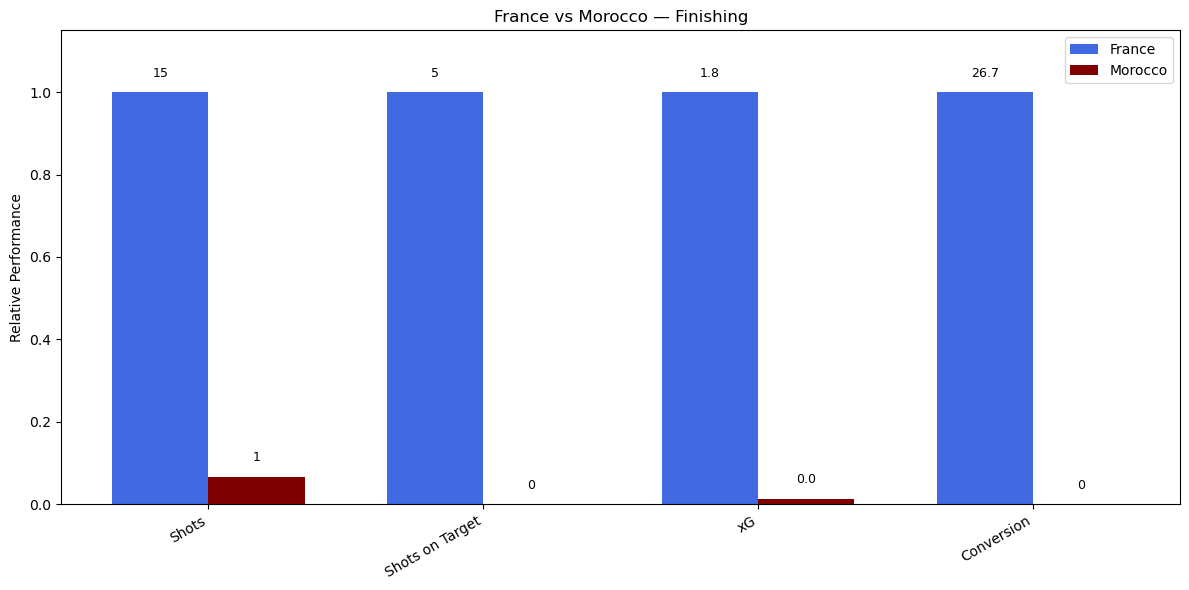

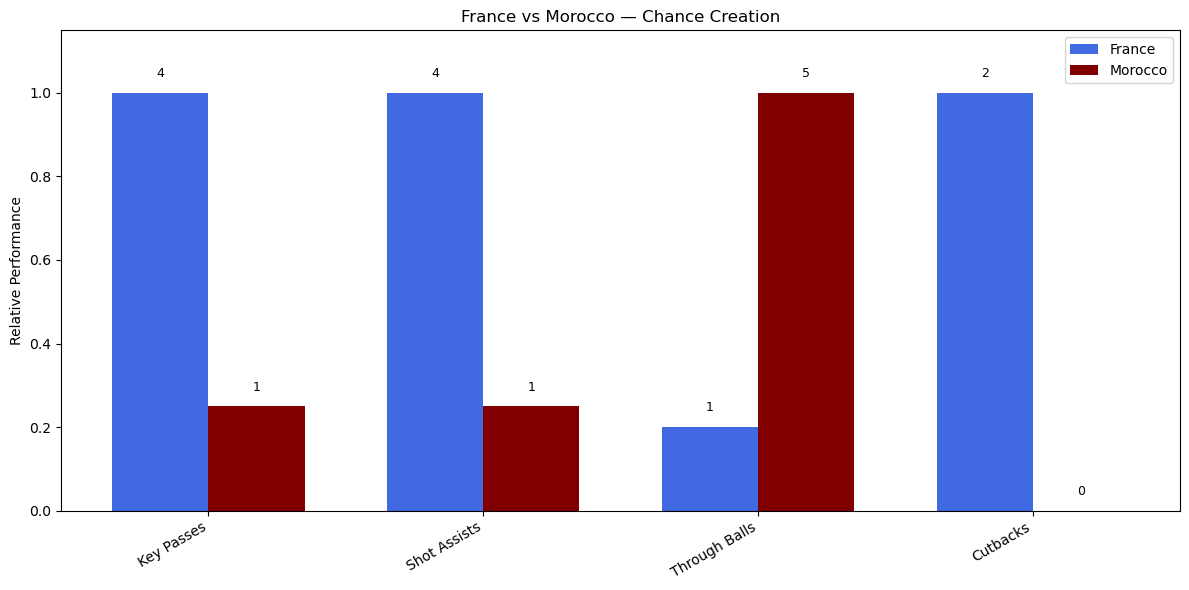

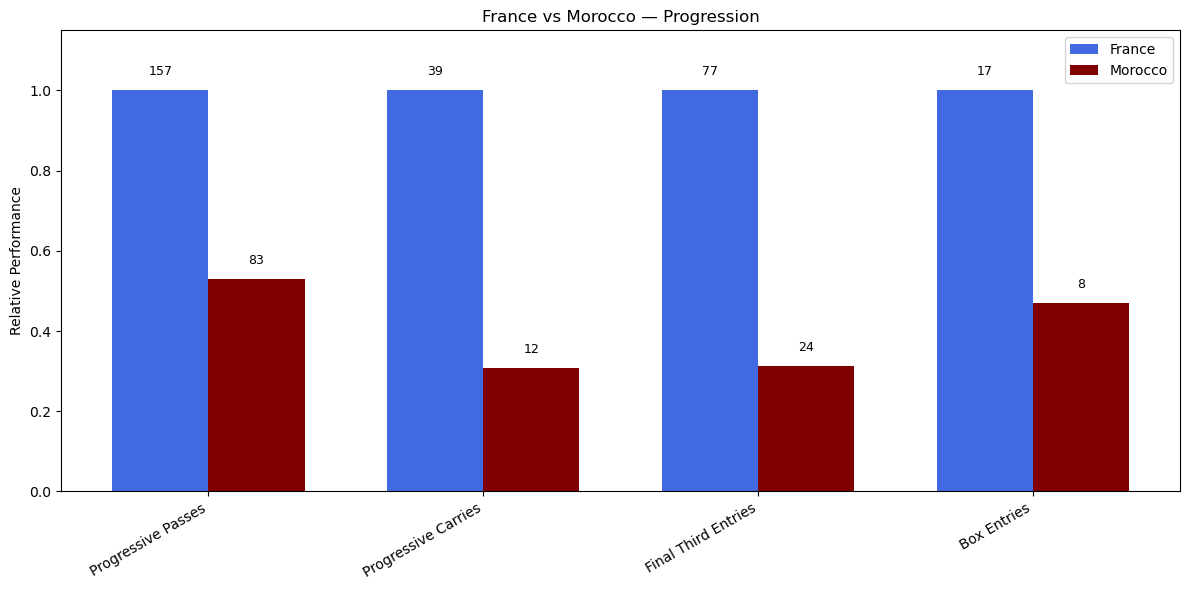

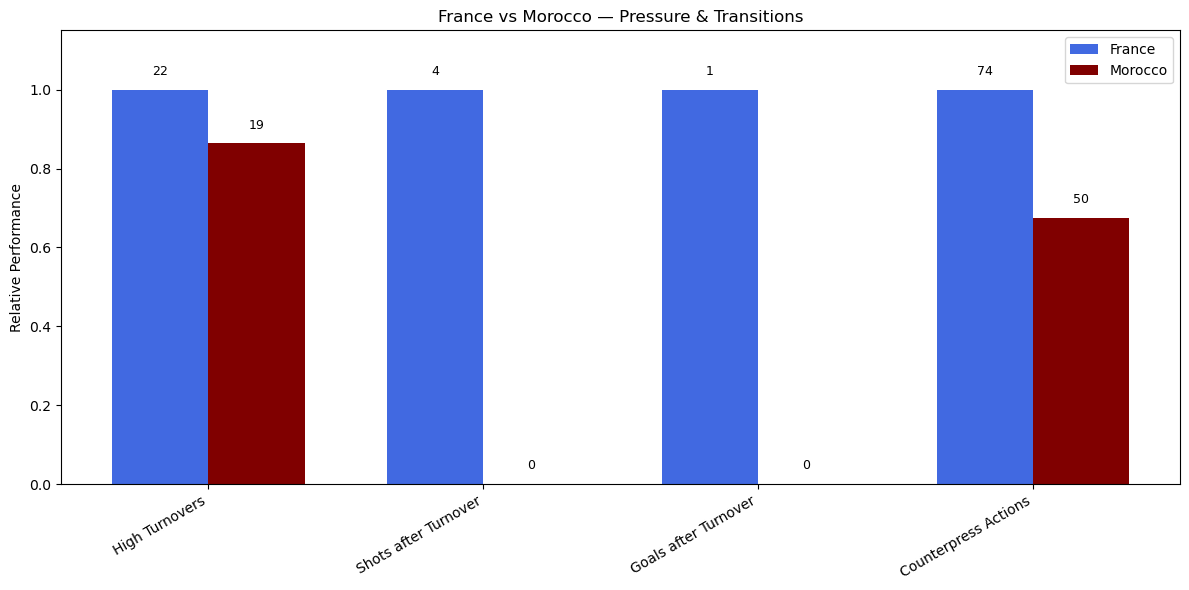

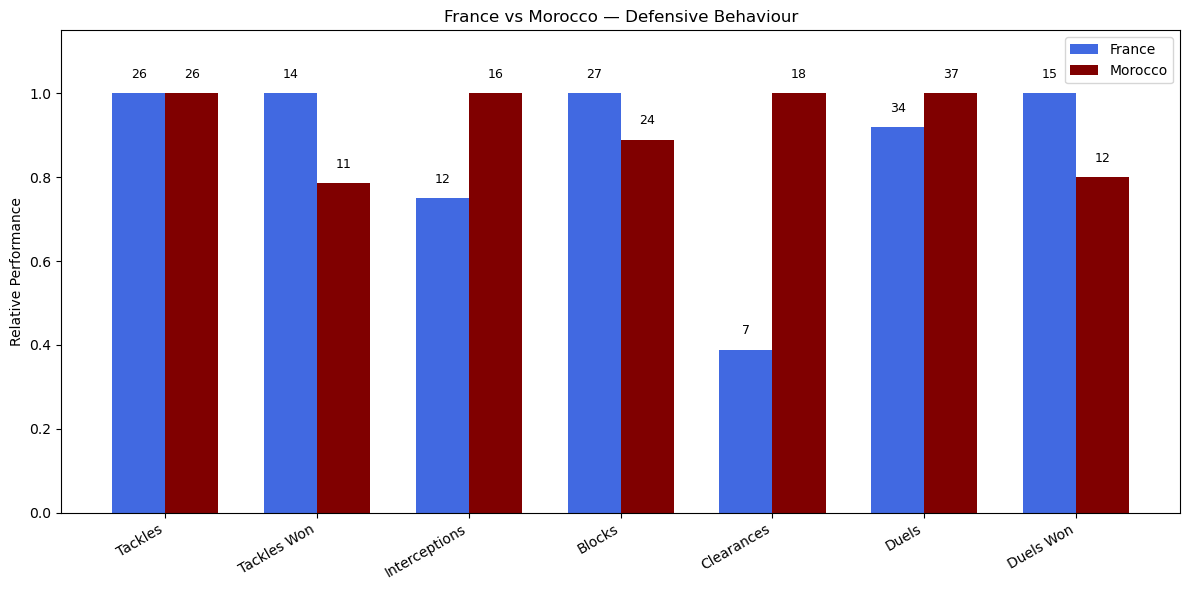

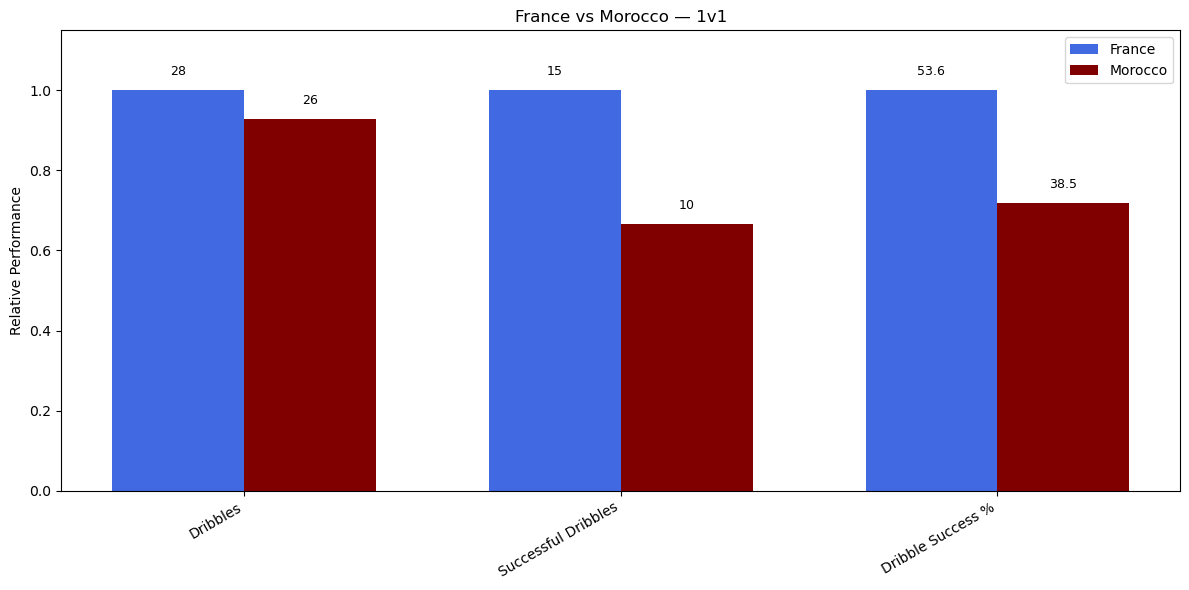

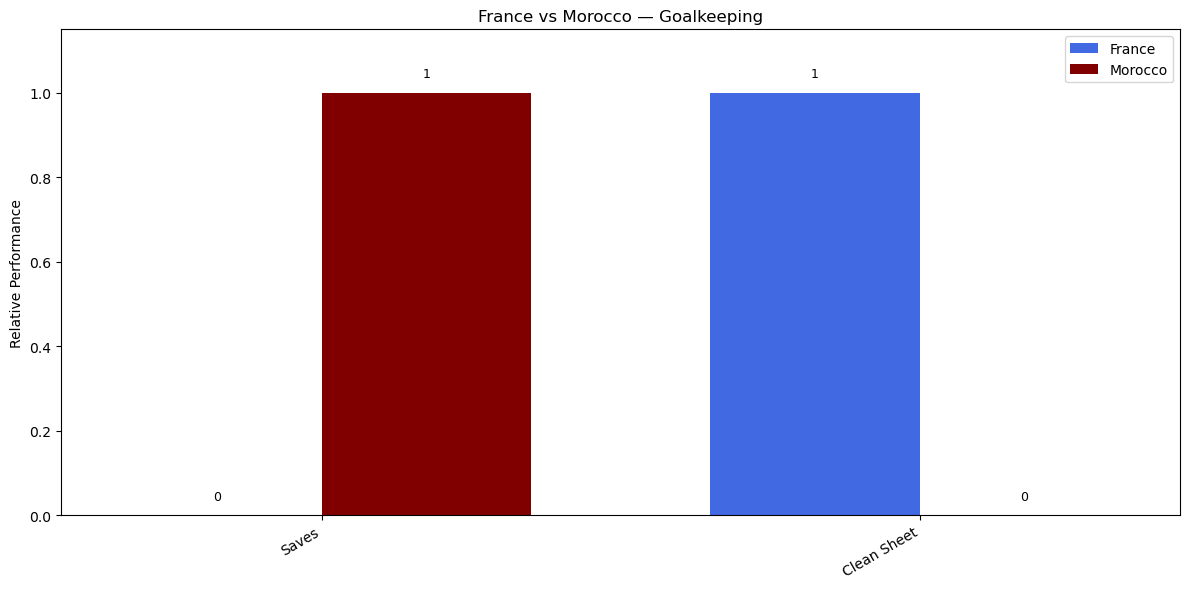

In [92]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "France Women's") &
        (womens_world_cup_stats["opponent"] == "Morocco Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Morocco Women's") &
        (womens_world_cup_stats["opponent"] == "France Women's")
    )
    &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()


# ============================================================
# 2. TEAM NAMES
# ============================================================

team_names = {
    "France": "France Women's",
    "Morocco": "Morocco Women's"
}


# ============================================================
# 3. METRICS BY CATEGORY
# ============================================================

categories = {


    "Finishing": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "xG": "xG",
        "Conversion": "conversion_pct"
    },


     "Chance Creation": {
        "Key Passes": "key_passes",
        "Shot Assists": "shot_assists",
        "Through Balls": "through_balls",
        "Cutbacks": "cutbacks"
    },



    "Progression": {
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries"
    },



    "Pressure & Transitions": {
        "High Turnovers": "high_turnovers",
        "Shots after Turnover": "shots_after_turnover",
        "Goals after Turnover": "goals_after_turnover",
        "Counterpress Actions": "counterpress_actions"
    },



    "Defensive Behaviour": {
        "Tackles": "tackles",
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Duels": "duels",
        "Duels Won": "duels_won"
    },



    "1v1": {
        "Dribbles": "dribbles",
        "Successful Dribbles": "successful_dribbles",
        "Dribble Success %": "dribble_success_pct"
    },



    "Goalkeeping": {
        "Saves": "saves",
        "Clean Sheet": "clean_sheet"
    }
}


# ============================================================
# 4. CHECK TEAMS
# ============================================================

print("Teams found:")
print(match["team"].unique())


# ============================================================
# 5. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # --------------------------------------------------------
    # Get real values
    # --------------------------------------------------------

    fra_values = np.array([
        match.loc[
            match["team"] == team_names["France"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)


    mor_values = np.array([
        match.loc[
            match["team"] == team_names["Morocco"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)


    # --------------------------------------------------------
    # Maximum value for each metric
    # --------------------------------------------------------

    max_values = np.maximum(
        fra_values,
        mor_values
    )


    # --------------------------------------------------------
    # Normalize
    # --------------------------------------------------------

    fra_normalized = np.divide(
        fra_values,
        max_values,
        out=np.zeros_like(fra_values),
        where=max_values != 0
    )


    mor_normalized = np.divide(
        mor_values,
        max_values,
        out=np.zeros_like(mor_values),
        where=max_values != 0
    )


    # --------------------------------------------------------
    # Position of bars
    # --------------------------------------------------------

    x = np.arange(len(metrics))
    width = 0.35


    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    plt.figure(figsize=(12, 6))


    bars_fra = plt.bar(
        x - width / 2,
        fra_normalized,
        width,
        label="France",
        color="royalblue"
    )


    bars_mor = plt.bar(
        x + width / 2,
        mor_normalized,
        width,
        label="Morocco",
        color="maroon"
    )


    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(
        bars_fra,
        fra_values
    ):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom",
            fontsize=9
        )


    for bar, value in zip(
        bars_mor,
        mor_values
    ):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom",
            fontsize=9
        )


    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"France vs Morocco — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

In [94]:
match[[
    "team",
    "opponent",
    "formation"
]]

,team,opponent,formation
110,France Women's,Morocco Women's,4-4-1-1
111,Morocco Women's,France Women's,4-4-2


In [96]:
formation_comparison = pd.DataFrame({
    "Metric": [
        "Formation",
        "Possession %",
        "Shots",
        "xG",
        "Progressive Passes",
        "Progressive Carries",
        "Final Third Entries",
        "Box Entries",
        "High Turnovers",
        "Interceptions",
        "Clearances"
    ],

    "France": [
        match.loc[
            match["team"] == "France Women's",
            "formation"
        ].iloc[0],
        
        match.loc[
            match["team"] == "France Women's",
            "possession_pct"
        ].iloc[0],
        
        match.loc[
            match["team"] == "France Women's",
            "shots"
        ].iloc[0],
        
        match.loc[
            match["team"] == "France Women's",
            "xG"
        ].iloc[0],
        
        match.loc[
            match["team"] == "France Women's",
            "progressive_passes"
        ].iloc[0],
        
        match.loc[
            match["team"] == "France Women's",
            "progressive_carries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "France Women's",
            "final_third_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "France Women's",
            "box_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "France Women's",
            "high_turnovers"
        ].iloc[0],
        
        match.loc[
            match["team"] == "France Women's",
            "interceptions"
        ].iloc[0],
        
        match.loc[
            match["team"] == "France Women's",
            "clearances"
        ].iloc[0]
    ],

    "Morocco": [
        match.loc[
            match["team"] == "Morocco Women's",
            "formation"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Morocco Women's",
            "possession_pct"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Morocco Women's",
            "shots"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Morocco Women's",
            "xG"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Morocco Women's",
            "progressive_passes"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Morocco Women's",
            "progressive_carries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Morocco Women's",
            "final_third_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Morocco Women's",
            "box_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Morocco Women's",
            "high_turnovers"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Morocco Women's",
            "interceptions"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Morocco Women's",
            "clearances"
        ].iloc[0]
    ]
})

# Arredondar percentagens e xG
formation_comparison.loc[
    formation_comparison["Metric"].isin(
        ["Possession %", "xG"]
    ),
    ["France", "Morocco"]
] = formation_comparison.loc[
    formation_comparison["Metric"].isin(
        ["Possession %", "xG"]
    ),
    ["France", "Morocco"]
].round(1)

formation_comparison

,Metric,France,Morocco
0,Formation,4-4-1-1,4-4-2
1,Possession %,73.375954,26.624046
2,Shots,15,1
3,xG,1.840469,0.024845
4,Progressive Passes,157.0,83.0
5,Progressive Carries,39.0,12.0
6,Final Third Entries,77.0,24.0
7,Box Entries,17.0,8.0
8,High Turnovers,22.0,19.0
9,Interceptions,12,16


## Conclusion FRA-MOR

France completely controlled the game, dominating possession, progression and attacking territory. Playing in a 4-4-1-1, their wider spacing and positioning allowed them to circulate the ball effectively while keeping the striker in a threatening position. Morocco, in a 4-4-2, struggled to maintain possession and progress the ball, despite having a formation that could have offered more balance in these areas. France also showed some inefficiency in finishing, with 15 shots but only 5 on target. However, their 4–0 victory and +2.16 Goals − xG show that they were highly effective when converting their chances. Morocco’s defensive numbers, particularly interceptions and clearances, reflect how much time they spent defending rather than controlling the game.